In [178]:
import os
from pathlib import Path
import json
from typing import List, Tuple, Dict, Optional, Sequence, Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.linalg import lstsq
from scipy.signal import butter, filtfilt, medfilt, welch
from scipy.stats import skew, kurtosis
from scipy.stats import entropy as _entropy
from scipy.stats import pointbiserialr

from sklearn.model_selection import GroupKFold, StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit

from __future__ import annotations
import math

# ONNX export
try:
    import onnx   # noqa: F401
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
except Exception:
    convert_sklearn = None

## 1. Configs & Visualization Utils
1.1. Configs

In [186]:
# CONFIGS

DATASET_DIR = "./UCI HAR Dataset/UCI HAR Dataset"
PROJECT_ROOT = Path.cwd().parent       # HARSYS/
DATA_ROOT = PROJECT_ROOT / "data"      # HARSYS/data
# NOTE "GENERAL" mode requires at least 3 subjects ! (for train/test/val)
MODE        = "per_person"     # "general" or "per_person"
SPLIT_MODE  = "block"     # or "block" (for individual person)
PERSON      = "veronica"          # or "paul", etc.

# Just make it match enum vals in Types.h
LABEL_NAME_TO_ID = {
    "walk": 0,
    "sit":   1,
    "stand":  2,
    "turn":  3,
    "inactive" : 4,
}
STAND_ID = LABEL_NAME_TO_ID["stand"]
SIT_ID   = LABEL_NAME_TO_ID["sit"]
WALK_ID  = LABEL_NAME_TO_ID["walk"]
TURN_ID  = LABEL_NAME_TO_ID["turn"]
INACTIVE_ID = LABEL_NAME_TO_ID["inactive"]

ACTIVITY_ORDER_BASE = ["stand", "walk", "sit", "turn"]

STATIC_CLASSES = ["stand", "sit"]
DYNAMIC_CLASSES = ["walk", "turn"]

# Separate SVM 1 and 0 class mappings (binary)
STATIC_PAIR_POS = {STAND_ID}   # stand = 1
STATIC_PAIR_NEG = {SIT_ID}     # sit   = 0

DYNAMIC_PAIR_POS = {WALK_ID}   # walk  = 1
DYNAMIC_PAIR_NEG = {TURN_ID}   # turn  = 0

STATIC_LABELS = {
    0: "Sit",
    1: "Stand",
}

DYN_LABELS = {
    0: "Turn",
    1: "Walk",
}

FS    = 119.0   # Hz (CLI overridable)
WIN   = 200     # samples (CLI)
HOP   = 100     # samples (CLI) 50% overlap
NUM_AXES = 3    # triaxial signal

AR_ORDER = 4
SEED      = 13 # Reproducibility

1.2. Data Visualization (Plotting Utils)

In [187]:
sns.set_context("notebook")
sns.set_style("whitegrid")

ACTIVITY_LABELS = {
    "stand": "Standing",
    "sit":   "Sitting",
    "walk":  "Walking",
    "turn":  "Turning",
    "inactive": "Inactive",
}

LABEL_ID_TO_DISPLAY = {
    LABEL_NAME_TO_ID[name]: pretty
    for name, pretty in ACTIVITY_LABELS.items()
}

STATIC_IDS  = {LABEL_NAME_TO_ID["stand"], LABEL_NAME_TO_ID["sit"]}
DYNAMIC_IDS = {LABEL_NAME_TO_ID["walk"],  LABEL_NAME_TO_ID["turn"]}

def to_intensity_labels(y_4class: np.ndarray) -> np.ndarray:
    """
    Map 4-class labels to binary intensity labels:
      0 = static   (stand, sit)
      1 = dynamic  (walk, turn)
    """
    y_4class = np.asarray(y_4class)
    return np.where(np.isin(y_4class, list(DYNAMIC_IDS)), 1, 0)

# Color palette per class (string key = raw label)
PALETTE = {
    "stand": "#914FAF",
    "sit":   "#F394C0",
    "walk":  "#5AB5E6",
    "turn":  "#FFB347",
}

RAW_COLOR = "#503EDC"

INTENSITY_LABELS = {
    0: "Static (sit/stand)",
    1: "Dynamic (walk/turn)",
}

# reuse colors from main PALETTE
INTENSITY_PALETTE = {
    0: PALETTE["sit"],   # static
    1: PALETTE["walk"],  # dynamic
}

def _intensity_to_display(c: int) -> str:
    return INTENSITY_LABELS.get(int(c), str(int(c)))


def _label_to_display(c, activity_map=ACTIVITY_LABELS):
    """Helper: map raw label (str/int) to display name."""
    return activity_map.get(c, str(c))

def _make_hue_palette(y_raw, activity_map=ACTIVITY_LABELS, palette=PALETTE):
    """
    y_raw: array of raw labels (e.g., 'stand','sit','walk','turn')
    Returns:
      hue_palette: {pretty_label -> color}
      disp: list of pretty labels
    """
    y_raw = np.asarray(y_raw)
    labs = np.unique(y_raw)
    disp = [_label_to_display(c, activity_map) for c in labs]
    cols = [palette.get(c, RAW_COLOR) for c in labs]
    return dict(zip(disp, cols)), disp


# 1) After initial loading: activity histogram (all 4 classes)
def plot_activity_histogram(y_ids,
                            activity_map=ACTIVITY_LABELS,
                            title="Raw Training Set: Activity Histograms",
                            color: str = RAW_COLOR,
                            top_pad: float = 0.12,
                            x_pad: float = 0.02):
    """
    y_ids: array-like of raw labels ("stand", "sit", "walk", "turn") or ints;
           activity_map maps them to pretty names.
    """
    y_ids = np.asarray(y_ids)
    ids, counts = np.unique(y_ids, return_counts=True)
    names = [_label_to_display(i, activity_map) for i in ids]

    order = np.argsort(counts)[::-1]
    counts_ord = counts[order]
    names_ord  = np.array(names)[order]

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(x=names_ord, y=counts_ord, color=color, ax=ax)

    ymax = counts_ord.max()
    ax.set_ylim(0, ymax * (1 + top_pad))
    ax.margins(x=x_pad)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

    ax.set_ylabel("Windows")
    ax.set_xlabel("Activity")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()


# 2) Single-split class balance (any label array, 4 classes)
def plot_class_balance(y,
                       activity_map=ACTIVITY_LABELS,
                       palette=PALETTE,
                       title="Class balance"):
    """
    y: array-like of raw labels ("stand", "sit", "walk", "turn" or subset).
    """
    y = np.asarray(y)
    labs, counts = np.unique(y, return_counts=True)
    names  = [_label_to_display(c, activity_map) for c in labs]
    colors = [palette.get(c, RAW_COLOR) for c in labs]

    plt.figure(figsize=(5, 4))
    sns.barplot(x=names, y=counts, palette=colors)
    for i, v in enumerate(counts):
        plt.text(i, v*1.01, str(v), ha="center", va="bottom", fontsize=9)
    plt.ylabel("Windows")
    plt.xlabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 3) After 65 / 20 / 15 split: side-by-side class balance (train/val/test)
def plot_split_balance(y_tr,
                       y_val,
                       y_test=None,
                       activity_map=ACTIVITY_LABELS,
                       palette=PALETTE,
                       title: str = "Class balance by split (65/20/15)",
                       top_pad: float = 0.12,
                       x_pad: float = 0.02):
    """
    y_tr, y_val, y_test: arrays of raw labels ("stand", "sit", "walk", "turn").
    For your project, typically:
      - y_tr : ~65% of data
      - y_val: ~20%
      - y_test: ~15% (held-out)
    """
    frames = [("Train (65%)", y_tr), ("Validation (20%)", y_val)]
    if y_test is not None:
        frames.append(("Test (15%)", y_test))

    rows = []
    for split_name, y_split in frames:
        y_split = np.asarray(y_split)
        labs, counts = np.unique(y_split, return_counts=True)
        for c, n in zip(labs, counts):
            rows.append({
                "Split": split_name,
                "Class": _label_to_display(c, activity_map),
                "Windows": int(n),
            })

    df = pd.DataFrame(rows)

    # Build hue palette based on classes actually present
    all_raw = np.concatenate([
        np.asarray(y_tr),
        np.asarray(y_val),
        np.asarray(y_test) if y_test is not None else np.array([], dtype=object)
    ])
    hue_palette, hue_order = _make_hue_palette(all_raw,
                                               activity_map=activity_map,
                                               palette=palette)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=df,
                x="Split", y="Windows",
                hue="Class",
                hue_order=sorted(hue_order),
                palette=hue_palette,
                ax=ax)

    heights = [p.get_height() for p in ax.patches if p.get_height() is not None]
    if heights:
        ax.set_ylim(0, max(heights) * (1 + top_pad))
    ax.margins(x=x_pad)

    for container in ax.containers:
        if hasattr(container, "datavalues"):
            ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

    ax.set_title(title)
    ax.set_ylabel("Windows")
    ax.set_xlabel("")
    ax.legend(title="Class")
    fig.tight_layout()
    plt.show()

# ======================= FEATURE ENGINEERING PLOTS ===========================
# “Feature vs label” scatter/box overlay (e.g., energy vs class)
def plot_feature_vs_label(X: np.ndarray, y: np.ndarray,
                          feature_names: Sequence[str],
                          feature_name: str,
                          activity_map=ACTIVITY_LABELS,
                          palette=PALETTE,
                          title: Optional[str] = None):
    """
    X: (n_samples, n_features)
    y: labels ("stand", "sit", "walk", "turn")
    feature_name: name of a single feature to plot vs class
    """
    y = np.asarray(y)
    idx = feature_names.index(feature_name)
    df = pd.DataFrame({
        feature_name: X[:, idx],
        "Class": [_label_to_display(c, activity_map) for c in y],
    })

    hue_palette, hue_order = _make_hue_palette(y, activity_map=activity_map, palette=palette)
    hue_order = sorted(hue_order)

    plt.figure(figsize=(5.8, 4))
    sns.stripplot(data=df,
                  x="Class", y=feature_name,
                  order=hue_order,
                  jitter=0.25,
                  palette=hue_palette,
                  alpha=0.6)
    sns.boxplot(data=df,
                x="Class", y=feature_name,
                order=hue_order,
                showcaps=True,
                boxprops={'facecolor': 'none'},
                showfliers=False,
                whiskerprops={'linewidth': 1},
                width=0.4)
    plt.title(title or f"{feature_name} vs Class")
    plt.tight_layout()
    plt.show()

def plot_feature_by_class(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    feature: str,
    activity_map=ACTIVITY_LABELS,
    palette=PALETTE,
    kind: str = "violin",
    title: str | None = None,
):
    if feature not in colnames:
        raise ValueError(f"{feature} not found in colnames.")
    idx = colnames.index(feature)

    y = np.asarray(y)
    df = pd.DataFrame({
        "value": Xf[:, idx],
        "Class": [_label_to_display(c, activity_map) for c in y],
    })

    # Build palette from raw labels y
    hue_palette, hue_order = _make_hue_palette(y,
                                               activity_map=activity_map,
                                               palette=palette)
    hue_order = sorted(hue_order)

    plt.figure(figsize=(6, 4))
    if kind == "box":
        sns.boxplot(data=df, x="Class", y="value",
                    order=hue_order,
                    palette=hue_palette)
    else:
        sns.violinplot(data=df, x="Class", y="value",
                       order=hue_order,
                       inner="quartile", cut=0, scale="width",
                       palette=hue_palette)
    plt.title(title or f"{feature} per class")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

def plot_features_grid_by_class(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    features: List[str],
    activity_map=ACTIVITY_LABELS,
    palette=PALETTE,
    kind: str = "violin",
    ncols: int = 3,
    suptitle: str | None = None,
):
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    y = np.asarray(y)
    df = pd.DataFrame({
        "Class": [_label_to_display(c, activity_map) for c in y]
    })
    for f in features:
        df[f] = Xf[:, colnames.index(f)]

    # Palette / order from raw labels
    hue_palette, hue_order = _make_hue_palette(y,
                                               activity_map=activity_map,
                                               palette=palette)
    hue_order = sorted(hue_order)

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(data=df, x="Class", y=fname,
                        order=hue_order,
                        palette=hue_palette,
                        ax=ax)
        else:
            sns.violinplot(data=df, x="Class", y=fname,
                           order=hue_order,
                           inner="quartile", cut=0, scale="width",
                           palette=hue_palette,
                           ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


def feature_corr_heatmap(
    Xf: np.ndarray,
    colnames: List[str],
    title: str = "Feature correlation (Pearson)",
):
    corr = pd.DataFrame(Xf, columns=colnames).corr()
    size = min(1 + 0.25 * len(colnames), 14)
    plt.figure(figsize=(size, min(size, 10)))
    sns.heatmap(corr, cmap="vlag", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Correlation ratio η²: "how much of feature variance is explained by class?" ----
def correlation_ratio_table(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: list[str],
) -> pd.DataFrame:
    """
    Compute correlation ratio η²(feature, class) for each feature.

    η² = SB / ST in ANOVA terms:
      SB = between-class sum of squares
      ST = total sum of squares

    Range ~ [0,1]. Higher = stronger dependence on class.
    Works for any number of classes.
    """
    Xf = np.asarray(Xf, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    n_features = Xf.shape[1]

    rows = []
    eps = 1e-12

    for j in range(n_features):
        f = Xf[:, j]
        mu = f.mean()
        ST = np.sum((f - mu) ** 2) + eps  # total variance * N

        SB = 0.0
        for c in classes:
            f_c = f[y == c]
            if f_c.size == 0:
                continue
            n_c = f_c.size
            mu_c = f_c.mean()
            SB += n_c * (mu_c - mu) ** 2

        eta2 = SB / ST
        rows.append((colnames[j], eta2))

    tb = (pd.DataFrame(rows, columns=["feature", "eta2"])
            .sort_values("eta2", ascending=False))
    return tb

def plot_feature_class_effects(
    eta_table: pd.DataFrame,
    top_k: int = 20,
    title: str = r"Feature–class effect sizes ($\eta^2$)",
):
    """
    Barplot of top-k features by correlation ratio η².
    eta_table: output of correlation_ratio_table(...)
    """
    tb = eta_table.copy()
    tb = tb.nlargest(top_k, "eta2")

    plt.figure(figsize=(8, 0.35 * len(tb)))
    sns.barplot(data=tb, x="eta2", y="feature", orient="h")
    plt.xlabel(r"Correlation ratio $\eta^2$ (variance explained by class)")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ======================= END FEATURE ENGINEERING PLOTS =======================

# ======== Class-wise summary stats ===========
def classwise_stats(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    activity_map=ACTIVITY_LABELS,
):
    """
    Returns (mean_df, median_df) per class (rows = pretty class names).
    Works for any number of classes.
    """
    y = np.asarray(y)
    df = pd.DataFrame(Xf, columns=colnames)
    df["Class"] = [_label_to_display(c, activity_map) for c in y]

    g = df.groupby("Class")
    out_mean = g.mean()
    out_med  = g.median()
    return out_mean, out_med

def fisher_scores(Xf, y, colnames):
    y = np.asarray(y)
    scores = []
    for i in range(Xf.shape[1]):
        f0 = Xf[y==0, i]; f1 = Xf[y==1, i]
        num = (np.mean(f1) - np.mean(f0))**2
        den = np.var(f1) + np.var(f0) + 1e-12
        scores.append(num/den)
    fs = pd.Series(scores, index=colnames).sort_values(ascending=False)
    return fs

def point_biserial_table(Xf, y, colnames):
    vals = []
    for i, name in enumerate(colnames):
        r, p = pointbiserialr(y, Xf[:, i])
        vals.append((name, r, p))
    tb = pd.DataFrame(vals, columns=["feature","r_pb","p_value"]).sort_values("r_pb", ascending=False)
    return tb

# ======================= INTENSITY (STATIC vs DYNAMIC) PLOTS =======================

def plot_intensity_feature(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    colnames: List[str],
    feature: str,
    kind: str = "violin",
    title: str | None = None,
):
    """
    Single-feature distribution for the intensity pre-classifier:

      - y_4class: 4-class window labels (0..3 or label IDs)
      - Internally mapped to:
            0 = Static (sit/stand)
            1 = Dynamic (walk/turn)

    kind: "violin" or "box"
    """
    if feature not in colnames:
        raise ValueError(f"{feature} not found in colnames.")
    idx = colnames.index(feature)

    # map 4-class -> intensity 0/1
    y_int = to_intensity_labels(y_4class)
    y_int = np.asarray(y_int)

    df = pd.DataFrame({
        "value": Xf[:, idx],
        "Intensity": [_intensity_to_display(c) for c in y_int],
    })

    order = [_intensity_to_display(0), _intensity_to_display(1)]
    palette = [INTENSITY_PALETTE[0], INTENSITY_PALETTE[1]]

    plt.figure(figsize=(5.8, 4))
    if kind == "box":
        sns.boxplot(
            data=df,
            x="Intensity",
            y="value",
            order=order,
            palette=palette,
        )
    else:
        sns.violinplot(
            data=df,
            x="Intensity",
            y="value",
            order=order,
            inner="quartile",
            cut=0,
            scale="width",
            palette=palette,
        )

    plt.xlabel("")
    plt.ylabel(feature)
    plt.title(title or f"{feature} — Static vs Dynamic")
    plt.tight_layout()
    plt.show()


def plot_intensity_features_grid(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    colnames: List[str],
    features: List[str],
    kind: str = "violin",
    ncols: int = 3,
    suptitle: str | None = "Pre-classifier features — Static vs Dynamic",
):
    """
    Grid of violin/box plots for the intensity pre-classifier.

      - y_4class: 4-class window labels
      - Internally mapped to:
            0 = Static (sit/stand)
            1 = Dynamic (walk/turn)
    """
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    y_int = to_intensity_labels(y_4class)
    y_int = np.asarray(y_int)

    df = pd.DataFrame({
        "Intensity": [_intensity_to_display(c) for c in y_int]
    })
    for f in features:
        df[f] = Xf[:, colnames.index(f)]

    order = [_intensity_to_display(0), _intensity_to_display(1)]
    palette = [INTENSITY_PALETTE[0], INTENSITY_PALETTE[1]]

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(
                data=df,
                x="Intensity",
                y=fname,
                order=order,
                palette=palette,
                ax=ax,
            )
        else:
            sns.violinplot(
                data=df,
                x="Intensity",
                y=fname,
                order=order,
                inner="quartile",
                cut=0,
                scale="width",
                palette=palette,
                ax=ax,
            )
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()

# ======================= END INTENSITY PLOTS =======================

def plot_pair_features_grid(
    X_pair: np.ndarray,
    y_pair_4class: np.ndarray,
    colnames: list[str],
    features: list[str],
    kind: str = "violin",
    ncols: int = 2,
    suptitle: str | None = None,
):
    """
    Grid of violin/box plots for a *pairwise* activity SVM:
      - X_pair:  (n_samples, n_features_subset)  (can be selected cols)
      - y_pair_4class: original 4-class integer labels (0..3) for these samples
      - colnames: names of the columns in X_pair
      - features: which features (by name) to plot (subset of colnames)

    Uses LABEL_ID_TO_DISPLAY to show nice class names:
      Sitting vs Standing, or Walking vs Turning.
    """
    y_pair_4class = np.asarray(y_pair_4class)

    # sanity: ensure all requested features exist in colnames
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    # map 4-class IDs -> pretty names ("Sitting", "Standing", ...)
    class_names = [LABEL_ID_TO_DISPLAY[int(c)] for c in y_pair_4class]

    df = pd.DataFrame({"Class": class_names})
    for fname in features:
        j = colnames.index(fname)
        df[fname] = X_pair[:, j]

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(data=df, x="Class", y=fname, ax=ax)
        else:
            sns.violinplot(
                data=df, x="Class", y=fname,
                inner="quartile", cut=0, scale="width",
                ax=ax,
            )
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    # turn off any unused subplots
    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()



## 2. Data Loading & Segmentation

2.1. Window Class & Associated Window Building Functions 

In [188]:
# columns in C++ training_windows.csv
TRAIN_COL_WINDOW_IDX = "window_idx"
TRAIN_COL_LABEL_ID   = "label_id"
TRAIN_COL_LABEL_NAME = "label_name"

# ========== window class ==========

class Window:
    def __init__(self):
        # Sequential index for bookkeeping (1,2,3,...)
        self.seq: int = 0
        # Flat window content: [x1,y1,z1, x2,y2,z2, ..., xL,yL,zL]
        self.window_arr: Optional[np.ndarray] = None
        # Raw label for this window (e.g., "stand", "sit", "walk", "turn" or an int code)
        self.window_label: Any = None
        # Optional metadata (useful for grouping later by subject or block)
        self.subject_id: Optional[str] = None
        self.block_id: Optional[int] = None
        self.block_uid: Optional[str] = None
        # Output of feature extraction:
        # By convention we store a tuple: (feature_vector: np.ndarray, feature_dict: Dict[str, float])
        self.features: Optional[Tuple[np.ndarray, Dict[str, float]]] = None

# ========== helpers: flat window <-> axes ==========

def split_xyz_from_flat(raw_flat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    raw_flat = [x1,y1,z1, x2,y2,z2, ...]  -> returns (x[], y[], z[]) each length L.
    Assumes 3 channels (x,y,z) in that order.
    """
    return raw_flat[0::3], raw_flat[1::3], raw_flat[2::3]

def flat_from_xyz_block(xyz_block: np.ndarray) -> np.ndarray:
    """
    xyz_block shape (L,3) -> flat [x1,y1,z1, x2,y2,z2, ...] in row-major order.
    """
    assert xyz_block.ndim == 2 and xyz_block.shape[1] == 3, "xyz_block must be [L,3]"
    return xyz_block.reshape(-1)


# ========== core window loader ==========

def load_windows_from_training_csv(
    csv_path: Path,
    subject_id: Optional[str] = None,
    block_prefix: Optional[str] = None,
) -> List[Window]:
    """
    Load pre-windowed data from C++ calibration-mode training CSV:
        window_idx,label_id,label_name,x0,y0,z0,...,xL-1,yL-1,zL-1

    Returns a list[Window] with:
      - seq          = window_idx
      - window_label = label_id (int)
      - window_arr   = flat [x1,y1,z1,...] as float
      - subject_id   = provided subject_id (optional)
      - block_uid    = f"{block_prefix or csv_stem}#w{seq}"
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    required = [TRAIN_COL_WINDOW_IDX, TRAIN_COL_LABEL_ID, TRAIN_COL_LABEL_NAME]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} is missing required columns: {missing}")

    # all raw sensor columns: x0,y0,z0,...,xL-1,yL-1,zL-1
    raw_cols = [c for c in df.columns if c.startswith(("x", "y", "z"))]
    if not raw_cols:
        raise ValueError(f"{csv_path} has no x*/y*/z* columns")

    if len(raw_cols) % 3 != 0:
        raise ValueError(f"{csv_path}: number of raw cols ({len(raw_cols)}) not divisible by 3")

    windows: List[Window] = []

    # default subject/block if not passed
    if subject_id is None:
        subject_id = csv_path.parent.name or csv_path.stem
    if block_prefix is None:
        block_prefix = csv_path.stem

    for _, row in df.iterrows():
        win = Window()
        # seq from CSV (int)
        win.seq = int(row[TRAIN_COL_WINDOW_IDX])
        # label as int (0..3) from C++
        win.window_label = int(row[TRAIN_COL_LABEL_ID])

        # flat window samples
        win.window_arr = row[raw_cols].to_numpy(dtype=float)

        win.subject_id = subject_id
        win.block_id = None   # optional, can fill later if you want
        win.block_uid = f"{block_prefix}#w{win.seq}"

        windows.append(win)

    return windows


# ========== stack features into a matrix ==========

def stack_features(windows: List[Window]) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Stack per-window features into a design matrix.

    Assumes each Window has:
        win.features = (feature_vec, feature_dict)
    with identical keys in feature_dict for all windows.

    Returns
    -------
    Xf : np.ndarray
        Shape [n_windows, n_features]
    yf : np.ndarray
        Shape [n_windows], labels (same type as window.window_label)
    colnames : List[str]
        Feature names in the same order as Xf columns.
    """
    usable = [w for w in windows if w.features is not None]
    if not usable:
        raise ValueError("No window has features. Make sure feature_func is provided to window_builder().")

    # Reference ordering of features from the first window
    _, first_dict = usable[0].features
    colnames = list(first_dict.keys())

    # Stack feature vectors in that order
    rows = []
    labels = []
    for w in usable:
        fv, fd = w.features
        # Rebuild row using dict order to be safe
        rows.append([fd[k] for k in colnames])
        labels.append(w.window_label)

    Xf = np.asarray(rows, dtype=float)
    yf = np.asarray(labels, dtype=object)

    return Xf, yf, colnames

2.2. Data Loading, Cleaning, Splitting & Visualization
- Define label mapping
- Builds contiguous windows from training blocks (when active == 1) and assigns their labels based on activity_order
- Does a group aware 65/20/15 split
- Handles mode "general" and mode "per-person" by splitting by subject IDs (general = no subject leakage) or block UIDs (per-person = no block leakage)
- Plots histograms & split balances to assess data

In [189]:
# ---------- Group-aware 65 / 20 / 15 split ----------
# This is generic group-awareness: will pass in groups by subject_id per window or block_uid per window based on mode.
def _groupwise_train_val_test_split(
    y: np.ndarray,
    groups: np.ndarray,
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    65 / 20 / 15 split with group awareness (no group leakage).
    Uses GroupShuffleSplit twice:
      1) train vs temp
      2) temp -> val vs test
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, "Fractions must sum to 1."

    y = np.asarray(y)
    groups = np.asarray(groups)

    # 1) train vs temp
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_frac, random_state=seed)
    train_idx, temp_idx = next(gss1.split(X=np.zeros_like(y), y=y, groups=groups))

    # 2) val vs test on temp
    temp_y = y[temp_idx]
    temp_groups = groups[temp_idx]
    rel_val = val_frac / (val_frac + test_frac)

    gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=seed + 1)
    val_rel_idx, test_rel_idx = next(
        gss2.split(X=np.zeros_like(temp_y), y=temp_y, groups=temp_groups)
    )
    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]

    return train_idx, val_idx, test_idx

def _stratified_train_val_test_split(
    y: np.ndarray,
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    65 / 20 / 15 split with *label stratification* (no grouping).
    Used for mode='per_person', so each split sees all 4 classes
    in similar proportions.
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    y = np.asarray(y)
    sss1 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=train_frac,
        random_state=seed,
    )
    train_idx, temp_idx = next(sss1.split(X=np.zeros_like(y), y=y))

    temp_y = y[temp_idx]
    rel_val = val_frac / (val_frac + test_frac)

    sss2 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=rel_val,
        random_state=seed + 1,
    )
    val_rel_idx, test_rel_idx = next(sss2.split(X=np.zeros_like(temp_y), y=temp_y))

    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]

    return train_idx, val_idx, test_idx


# ---------- Top-level loader: general vs per-person ----------

def load_training_windows_for_svm(
    mode: str = "general",          # "general" or "per_person"
    data_root: str = "data_cpp",    # base folder containing per-person subdirs
    person: str | None = None,      # required if mode == "per_person"
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    Load pre-windowed C++ training CSVs (training_windows.csv) and
    prepare train/val/test splits.

    Assumed layout:

    mode="general":
        data_root/<person1>/training_windows.csv
        data_root/<person2>/training_windows.csv
        ...

    mode="per_person":
        data_root/<person>/training_windows.csv
    """
    data_root_path = Path(data_root)
    windows: list[Window] = []

    if mode == "per_person":
        if person is None:
            raise ValueError("mode='per_person' requires `person`.")
        base = data_root_path / person
        csvs = sorted(base.glob("training_windows*.csv"))
        if not csvs:
            raise FileNotFoundError(f"No training_windows*.csv found for person '{person}' in {base}")
        print(f"[MODE] Per-person: {person}")
        for csv_path in csvs:
            w = load_windows_from_training_csv(
                csv_path=csv_path,
                subject_id=person,
                block_prefix=csv_path.stem,
            )
            print(f"[LOAD:{person}] {csv_path.name}: {len(w)} windows")
            windows.extend(w)

    elif mode == "general":
        # Look for per-person subfolders under data_root
        person_dirs = [d for d in data_root_path.iterdir() if d.is_dir()]
        if not person_dirs:
            raise FileNotFoundError(
                f"No subject folders found in {data_root_path} "
                "(expected data_root/<person>/training_windows*.csv)"
            )
        person_dirs = sorted(person_dirs)
        print(f"[MODE] General (multi-subject). Subject folders in {data_root_path}: {len(person_dirs)}")

        for person_dir in person_dirs:
            person_id = person_dir.name
            csvs = sorted(person_dir.glob("training_windows*.csv"))
            if not csvs:
                print(f"[WARN] No training_windows*.csv for subject '{person_id}' in {person_dir}, skipping.")
                continue
            for csv_path in csvs:
                w = load_windows_from_training_csv(
                    csv_path=csv_path,
                    subject_id=person_id,
                    block_prefix=csv_path.stem,
                )
                print(f"[LOAD:{person_id}] {csv_path.name}: {len(w)} windows")
                windows.extend(w)
    else:
        raise ValueError(f"Unknown mode '{mode}' (use 'general' or 'per_person').")

    if not windows:
        raise RuntimeError("No windows constructed; check data_root and training_windows.csv files.")

    # --- Build y and groups arrays ---
    y_all = np.asarray([w.window_label for w in windows], dtype=int)

    if mode == "general":
        groups = np.asarray([w.subject_id for w in windows], dtype=object)
    else:
        # per-person: group by block_uid so windows from same recording stay together
        groups = np.asarray([w.block_uid for w in windows], dtype=object)

    # --- Plot overall histogram before splitting ---
    def _activity_map_for_plot():
        # map 0,1,2,3 -> "Standing", "Sitting", ...
        return {k: v for k, v in LABEL_ID_TO_DISPLAY.items()}

    plot_activity_histogram(
        y_ids=y_all,
        activity_map=_activity_map_for_plot(),
        title=f"Raw window set (C++): activity histogram ({mode})",
    )

    # --- Group-aware 65/20/15 split ---
    if mode == "general":
        idx_tr, idx_val, idx_te = _groupwise_train_val_test_split(
            y=y_all,
            groups=groups,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            seed=seed,
        )
    else:
        idx_tr, idx_val, idx_te = _stratified_train_val_test_split(
            y=y_all,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            seed=seed,
        )

    y_tr, y_val, y_te = y_all[idx_tr], y_all[idx_val], y_all[idx_te]
    print("All windows label counts:", dict(zip(*np.unique(y_all, return_counts=True))))
    print("TRAIN label counts:",      dict(zip(*np.unique(y_tr,  return_counts=True))))
    print("VAL label counts:",        dict(zip(*np.unique(y_val, return_counts=True))))
    print("TEST label counts:",       dict(zip(*np.unique(y_te,  return_counts=True))))

    plot_split_balance(
        y_tr,
        y_val,
        y_te,
        title=f"Class balance by split (C++ windows, {mode})",
    )

    if mode == "general":
        subs_tr = {windows[i].subject_id for i in idx_tr}
        subs_val = {windows[i].subject_id for i in idx_val}
        subs_te  = {windows[i].subject_id for i in idx_te}
        print("Subject overlap train/val?", len(subs_tr & subs_val) > 0)
        print("Subject overlap train/test?", len(subs_tr & subs_te) > 0)
    else:
        bl_tr = {windows[i].block_uid for i in idx_tr}
        bl_val = {windows[i].block_uid for i in idx_val}
        bl_te  = {windows[i].block_uid for i in idx_te}
        print("Block overlap train/val?", len(bl_tr & bl_val) > 0)
        print("Block overlap train/test?", len(bl_tr & bl_te) > 0)

    return windows, y_all, groups, idx_tr, idx_val, idx_te



# 3. Feature Engineering

## 3.1. Feature Extraction Helpers

In [ ]:
def mag_from_xyz(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> np.ndarray:
    return np.sqrt(x*x + y*y + z*z)

def _as_float(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

def mean(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.mean(x))

def std(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.std(x))

def rms(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.sqrt(np.mean(x*x)))

def mad(x: np.ndarray) -> float:
    x = _as_float(x);  m = np.median(x)
    return float(np.median(np.abs(x - m)))

def iqr(x: np.ndarray) -> float:
    x = _as_float(x)
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)

def axis_corr(a: np.ndarray, b: np.ndarray) -> float:
    a, b = _as_float(a), _as_float(b)
    if a.size < 2 or b.size < 2: return 0.0
    aa, bb = a - a.mean(), b - b.mean()
    sa, sb = aa.std(), bb.std()
    if sa == 0.0 or sb == 0.0: return 0.0
    return float(np.mean(aa*bb) / (sa*sb))

def _cxx_psd(sig: np.ndarray, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Naive DFT-based PSD to match the C++ implementation exactly:

        size_t K = N/2 + 1;
        for (k = 0; k < K; ++k) {
            omega = -2.0 * 3.14 * k / N;
            re = sum_n x[n] * cos(omega * n);
            im = sum_n x[n] * sin(omega * n);
            P[k] = (re^2 + im^2) / N;
            f[k] = fs * k / N;
        }

    Returns:
        f: shape (K,)
        P: shape (K,)
    """
    s = _as_float(sig)
    N = s.size
    if N == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    K = N // 2 + 1
    f = np.empty(K, dtype=float)
    P = np.empty(K, dtype=float)

    for k in range(K):
        omega = -2.0 * 3.14 * float(k) / float(N)  # match C++: uses 3.14, not pi
        re = 0.0
        im = 0.0
        for n in range(N):
            angle = omega * float(n)
            val = float(s[n])
            re += val * math.cos(angle)
            im += val * math.sin(angle)
        mag2 = (re * re + im * im) / float(N)
        f[k] = fs * float(k) / float(N)
        P[k] = mag2

    return f, P

def _bandpower(f: np.ndarray, P: np.ndarray, lo: float, hi: float) -> float:
    m = (f >= lo) & (f < hi)
    if not np.any(m): return 0.0
    return float(np.trapz(P[m], f[m]))

# ===== TIME DOMAIN FEATURES =====
# per-axis stats (x,y,z)
def mean_axis(x,y,z, axis: str) -> float:
    return mean({'x':x, 'y':y, 'z':z}[axis])

def std_axis(x,y,z, axis: str) -> float:
    return std({'x':x, 'y':y, 'z':z}[axis])

def rms_axis(x,y,z, axis: str) -> float:
    return rms({'x':x, 'y':y, 'z':z}[axis])

def mad_axis(x,y,z, axis: str) -> float:
    return mad({'x':x, 'y':y, 'z':z}[axis])

def iqr_axis(x,y,z, axis: str) -> float:
    return iqr({'x':x, 'y':y, 'z':z}[axis])

def _zero_cross_rate(sig: np.ndarray) -> float:
    """
    Zero-crossing rate of a 1D signal.
    """
    s = _as_float(sig)
    if s.size < 2:
        return 0.0
    # remove DC to make sign changes more meaningful
    s = s - s.mean()
    signs = np.sign(s)
    # treat zeros as continuity -> shift to previous non-zero sign
    for i in range(1, signs.size):
        if signs[i] == 0:
            signs[i] = signs[i-1]
    zc = np.count_nonzero(signs[1:] * signs[:-1] < 0)
    return float(zc / (s.size - 1))

# magnitude features
def sma_xyz(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    x, y, z = _as_float(x), _as_float(y), _as_float(z)
    N = max(1, x.size)
    return float((np.sum(np.abs(x)) + np.sum(np.abs(y)) + np.sum(np.abs(z))) / N)

def mean_mag(x,y,z): return mean(mag_from_xyz(x,y,z))
def std_mag(x,y,z):  return std(mag_from_xyz(x,y,z))
def rms_mag(x,y,z):  return rms(mag_from_xyz(x,y,z))
def mad_mag(x,y,z):  return mad(mag_from_xyz(x,y,z))
def iqr_mag(x,y,z):  return iqr(mag_from_xyz(x,y,z))
def ptp_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    """
    Peak-to-peak range of the acceleration magnitude.
    """
    m = _as_float(mag_from_xyz(x, y, z))
    if m.size == 0:
        return 0.0
    return float(m.max() - m.min())
def zcr_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    """
    Zero-crossing rate of the acceleration magnitude.
    (After DC removal, so it behaves like an oscillatory signal.)
    """
    m = _as_float(mag_from_xyz(x, y, z))
    return _zero_cross_rate(m)

# correlations between axes
def xy_corr(x,y,z): return axis_corr(x,y)
def yz_corr(x,y,z): return axis_corr(y,z)
def zx_corr(x,y,z): return axis_corr(z,x)

# CUSTOM FEATURES
# (1) Custom Feature: tilt_variability
# --> describes angle wrt horizontal plane (z) which increases with dynamic motion
# (2) Custom Feature: vertical_acceleration_ratio
# --> describes vertical acceleration (aligned with g) normalized by horizontal components
# --> during dynamic activities -> vertical oscillations dominate (leg push-off, heel strike) hence large vertical_acceleration_ratio value
def vertical_acceleration_ratio(x,y,z):
    psi = np.std(z)/(np.std(x)+np.std(y)+1e-6) # avoid div by 0
    return float(psi)
def tilt_variability(x,y,z):
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    tilt = np.arctan2(z, np.sqrt(x*x + y*y))
    return float(np.std(tilt))

# ===== TIME-FREQUENCY DOMAIN: AR(p) on magnitude =====
def ar_coeffs_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, p: int = 4) -> Tuple[np.ndarray, float]:
    m = _as_float(mag_from_xyz(x,y,z))
    m = m - m.mean()
    if m.size <= p + 2:
        return np.zeros(p, dtype=float), 0.0
    N = m.size
    Y = m[p:]
    X = np.column_stack([m[p - i - 1: N - i - 1] for i in range(p)])
    a, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ a
    return a.astype(float), float(np.var(resid))

# ===== FREQUENCY DOMAIN: PSD / FFT magnitudes =====
_BANDS = {
    "bp_0p5_3":  (0.5, 3.0),   # gait
    "bp_3_8":    (3.0, 8.0),   # stairs / higher harmonics
    "bp_8_15":   (8.0, 15.0),
}

def total_power_mag(x, y, z, fs: float) -> float:
    """
    Match C++ total_power_mag:
      - compute PSD via _cxx_psd
      - return sum of P (no trapezoidal integration).
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0
    return float(np.sum(P))


def bandpowers_mag(x, y, z, fs: float) -> Dict[str, float]:
    """
    Match C++ bandpower_mag:
      - same PSD as C++
      - bandpower = sum of P[k] where f[k] in [lo, hi] (inclusive).
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return {k: 0.0 for k in _BANDS}

    out: Dict[str, float] = {}
    for name, (lo, hi) in _BANDS.items():
        mask = (f >= lo) & (f <= hi)  # inclusive bounds like C++
        if not np.any(mask):
            out[name] = 0.0
        else:
            out[name] = float(np.sum(P[mask]))
    return out


def spectral_entropy_mag(x, y, z, fs: float) -> float:
    """
    Match updated C++ spectral_entropy_mag:

        - compute PSD via _cxx_psd
        - P_clipped = max(P, 0)
        - sumP = sum(P_clipped)
        - pk = P_clipped / sumP
        - H_nat = -sum pk * log(pk)       (natural log)
        - H_bits = H_nat / log(2.0)      (convert nats -> bits)

    Returns H_bits.
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0

    P_clipped = np.maximum(P, 0.0)
    sumP = float(np.sum(P_clipped))
    if sumP <= 0.0:
        return 0.0

    pk = P_clipped / sumP
    mask = pk > 0.0
    if not np.any(mask):
        return 0.0

    H_nat = float(-np.sum(pk[mask] * np.log(pk[mask])))
    H_bits = H_nat / math.log(2.0)
    return float(H_bits)


def spec_centroid_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Match C++ spec_centroid_mag:
      centroid = sum(f * P) / sum(P)
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0

    num = float(np.sum(f * P))
    den = float(np.sum(P))
    if den <= 0.0:
        return 0.0
    return float(num / den)


def dom_freq_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Match C++ dom_freq_mag: frequency at PSD max bin.
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0
    idx = int(np.argmax(P))
    return float(f[idx])


def spec_bandwidth_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Match C++ spec_bandwidth_mag:
      - centroid as above
      - var = sum(P * (f - centroid)^2) / sum(P)
      - bandwidth = sqrt(var)
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0

    den = float(np.sum(P))
    if den <= 0.0:
        return 0.0

    centroid = float(np.sum(f * P) / den)
    var = float(np.sum(((f - centroid) ** 2) * P) / den)
    if var < 0.0:
        var = 0.0
    return float(np.sqrt(var))


def spec_flatness_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Match C++ spec_flatness_mag:
      - v = P + eps
      - geo_mean = exp( mean(log(v)) )
      - ar_mean  = mean(v)
      - flatness = geo_mean / ar_mean
    """
    f, P = _cxx_psd(mag_from_xyz(x, y, z), fs)
    if P.size == 0:
        return 0.0

    eps = 1e-12
    v = P + eps
    log_sum = float(np.sum(np.log(v)))
    lin_sum = float(np.sum(v))
    K = float(v.size)
    geo_mean = math.exp(log_sum / K)
    ar_mean = lin_sum / K
    if ar_mean <= 0.0:
        return 0.0
    return float(geo_mean / ar_mean)


# ===== FEATURE REGISTRY =====
# base feature functions that take (x,y,z[,fs]) and return a scalar
FeatureFn = Callable[..., float]
FEATURES: Dict[str, Callable[..., float]] = {
    # magnitude scalars
    "sma_xyz": sma_xyz,
    "mean_mag": mean_mag, "std_mag": std_mag, "rms_mag": rms_mag,
    "mad_mag": mad_mag, "iqr_mag": iqr_mag,
    "xy_corr": xy_corr, "yz_corr": yz_corr, "zx_corr": zx_corr,
    # PSD
    "total_power_mag": total_power_mag,
    "spectral_entropy_mag": spectral_entropy_mag,
    # AR
    "ar_mag_coeffs": ar_coeffs_mag,
    # bandpower expansions are handled in compute_features
    "tilt_variability": tilt_variability,
    "vertical_acceleration_ratio": vertical_acceleration_ratio,
    "ptp_mag": ptp_mag,
    "zcr_mag": zcr_mag,
    "dom_freq_mag": dom_freq_mag,
    "spec_centroid_mag": spec_centroid_mag,
    "spec_bandwidth_mag": spec_bandwidth_mag,
    "spec_flatness_mag": spec_flatness_mag,
}
# per-axis templates -> expand to _x/_y/_z
_PER_AXIS_TEMPLATES = {
    "mean": mean_axis,
    "std": std_axis,
    "rms": rms_axis,
    "mad": mad_axis,
    "iqr": iqr_axis,
}

def compute_features(
    x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float,
    feature_names: List[str], ar_order: int = 4
) -> Tuple[np.ndarray, Dict[str, float]]:
    """
    Evaluate requested features in order.
    - Per-axis requests can be specified either:
        'mean_axis'  -> expands to mean_x, mean_y, mean_z
      or explicitly as:
        'mean_x', 'std_y', 'rms_z', ...
    - 'ar_mag_coeffs' expands to ar_order coeffs + residual variance.
    - 'bandpowers_mag' expand to multiple outputs.
    Returns (vector, dict of name->value in the same order).
    - Index 0 (vector): 1D NumPy array of the ftr values in a fixed order
    - Index 1 (dict): a {feature_name: value} mapping in the same order the vector was built
    """
    vals: List[float] = []
    out: Dict[str, float] = {}

    def _add(name: str, value: float):
        vals.append(float(value)); out[name] = float(value)

    for name in feature_names:
        # expand templates like "mean_axis" -> x,y,z
        if name.endswith("_axis") and name[:-5] in _PER_AXIS_TEMPLATES:
            base = name[:-5]
            fn = _PER_AXIS_TEMPLATES[base]
            for ax in ("x","y","z"):
                v = fn(x,y,z, ax)
                _add(f"{base}_{ax}", v)
            continue

        # explicit per-axis like "std_x"
        if "_" in name and name.split("_",1)[0] in _PER_AXIS_TEMPLATES and name[-2:] in {"_x","_y","_z"}:
            base, ax = name.split("_",1)
            fn = _PER_AXIS_TEMPLATES[base]
            v = fn(x,y,z, ax)
            _add(name, v)
            continue

        if name == "bandpowers_mag":
            bp = bandpowers_mag(x,y,z,fs)
            for k, v in bp.items():
                _add(k, v)
            continue

        if name == "ar_mag_coeffs":
            a, var = ar_coeffs_mag(x,y,z, p=ar_order)
            for i, c in enumerate(a, 1):
                _add(f"ar{ar_order}_c{i}", c)
            _add(f"ar{ar_order}_resvar", var)
            continue

        # scalar magnitude or correlation or PSD/entropy
        fn = FEATURES[name]
        if fn in {
            total_power_mag,
            spectral_entropy_mag,
            dom_freq_mag,
            spec_centroid_mag,
            spec_bandwidth_mag,
            spec_flatness_mag,
        }:
            v = fn(x, y, z, fs)
        else:
            v = fn(x, y, z)
        _add(name, v)

    return np.asarray(vals, dtype=float), out

def attach_features_to_windows(
    windows,
    fs: float,
    feature_names: list[str],
    ar_order: int = 4,
):
    """
    Mutates each Window in-place:
      - reads w.window_arr (flat [x1,y1,z1,...])
      - computes fv, fv_dict via compute_features(...)
      - stores w.features = (fv, fv_dict)
    """
    for w in windows:
        if w.window_arr is None:
            raise ValueError("Window has no raw data (window_arr is None).")
        xw, yw, zw = split_xyz_from_flat(w.window_arr)
        fv, fv_dict = compute_features(
            xw, yw, zw,
            fs=fs,
            feature_names=feature_names,
            ar_order=ar_order,
        )
        w.features = (fv, fv_dict)


## 3.2. Initial Feature Extraction (All Ftrs)

[MODE] Per-person: veronica
[LOAD:veronica] training_windows_veronica_1.csv: 5627 windows
[LOAD:veronica] training_windows_veronica_2.csv: 8724 windows
[LOAD:veronica] training_windows_veronica_3.csv: 4363 windows


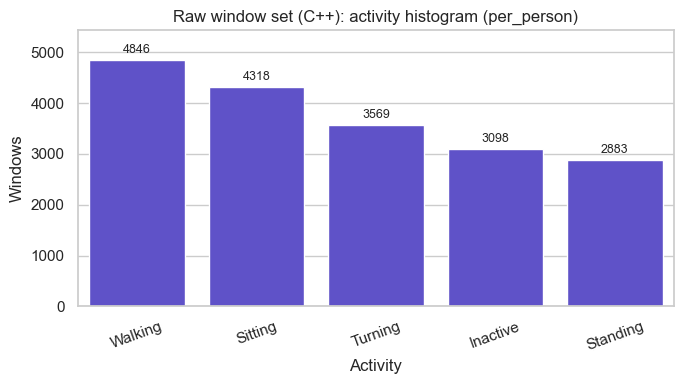

All windows label counts: {np.int64(0): np.int64(4846), np.int64(1): np.int64(4318), np.int64(2): np.int64(2883), np.int64(3): np.int64(3569), np.int64(4): np.int64(3098)}
TRAIN label counts: {np.int64(0): np.int64(3150), np.int64(1): np.int64(2806), np.int64(2): np.int64(1874), np.int64(3): np.int64(2320), np.int64(4): np.int64(2014)}
VAL label counts: {np.int64(0): np.int64(969), np.int64(1): np.int64(864), np.int64(2): np.int64(576), np.int64(3): np.int64(714), np.int64(4): np.int64(619)}
TEST label counts: {np.int64(0): np.int64(727), np.int64(1): np.int64(648), np.int64(2): np.int64(433), np.int64(3): np.int64(535), np.int64(4): np.int64(465)}


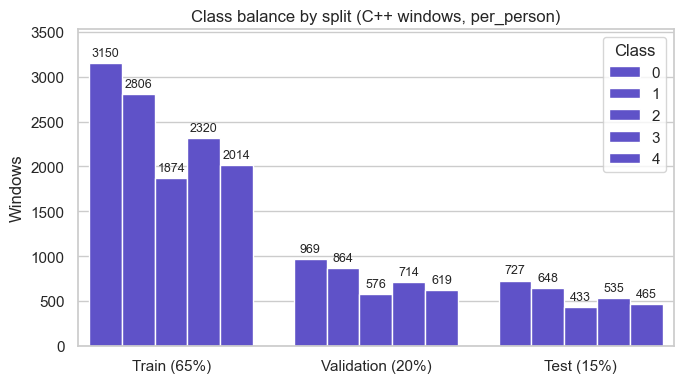

Block overlap train/val? False
Block overlap train/test? False
#windows (ACTIVE ONLY): train=10150, val=3123, test=2343
Unique labels in TRAIN: [0 1 2 3]


In [191]:
INACTIVE_ID = 4
ACTIVE_IDS = {0, 1, 2, 3}   # just for clarity

def drop_inactive(windows, inactive_id=INACTIVE_ID):
    """Filter out windows whose label is the inactive class."""
    return [w for w in windows if w.window_label != inactive_id]

# ================== 1) LOAD WINDOWS & GROUPWISE SPLIT ==================
windows, y_all, groups, idx_tr, idx_val, idx_te = load_training_windows_for_svm(
    mode=MODE,          # "per_person" or "general"
    data_root=DATA_ROOT,  # HARSys/data
    person=PERSON,      # "veronica" when MODE == "per_person"
    train_frac=0.65,
    val_frac=0.20,
    test_frac=0.15,
    seed=SEED,
)

# build window subsets per split
windows_tr  = [windows[i] for i in idx_tr]
windows_val = [windows[i] for i in idx_val]
windows_te  = [windows[i] for i in idx_te]

# drop inactive class 4 before any feature extraction
windows_tr  = drop_inactive(windows_tr)
windows_val = drop_inactive(windows_val)
windows_te  = drop_inactive(windows_te)

# rebuild y_* from the filtered windows so labels match 1-to-1
y_tr  = np.array([w.window_label for w in windows_tr], dtype=int)
y_val = np.array([w.window_label for w in windows_val], dtype=int)
y_te  = np.array([w.window_label for w in windows_te], dtype=int)

print(f"#windows (ACTIVE ONLY): train={len(windows_tr)}, val={len(windows_val)}, test={len(windows_te)}")
print("Unique labels in TRAIN:", np.unique(y_tr))


In [192]:
# ================== 2) FEATURE EXTRACTION ON EACH SPLIT ==================

# all features (36 total)
selected_features = [
    "mean_axis", "std_axis", "rms_axis", "mad_axis", "iqr_axis",
    "sma_xyz",
    "mean_mag", "std_mag", "rms_mag", "mad_mag", "iqr_mag",
    "total_power_mag",
    "bandpowers_mag",
    "spectral_entropy_mag",
    "ar_mag_coeffs",
    "tilt_variability", "vertical_acceleration_ratio",
    "xy_corr", "yz_corr", "zx_corr",
    "ptp_mag",
    "zcr_mag",
    "dom_freq_mag", "spec_centroid_mag", "spec_bandwidth_mag", "spec_flatness_mag"
]

# attach features in-place
attach_features_to_windows(windows_tr,  fs=FS, feature_names=selected_features, ar_order=4)
attach_features_to_windows(windows_val, fs=FS, feature_names=selected_features, ar_order=4)
attach_features_to_windows(windows_te,  fs=FS, feature_names=selected_features, ar_order=4)

# stack into matrices
Xf_tr, yf_tr, feat_names = stack_features(windows_tr)
Xf_val, yf_val, _        = stack_features(windows_val)
Xf_te,  yf_te,  _        = stack_features(windows_te)

y_int_tr  = to_intensity_labels(yf_tr)
y_int_val = to_intensity_labels(yf_val)
y_int_te  = to_intensity_labels(yf_te)

print("TRAIN feature matrix:", Xf_tr.shape)
print("VAL   feature matrix:", Xf_val.shape)
print("TEST  feature matrix:", Xf_te.shape)

# ================== 3) CLASSWISE SUMMARY STATS ==================

mean_tbl_tr, med_tbl_tr = classwise_stats(Xf_tr, yf_tr, feat_names)
mean_tbl_val, med_tbl_val = classwise_stats(Xf_val, yf_val, feat_names)
mean_tbl_te,  med_tbl_te  = classwise_stats(Xf_te,  yf_te,  feat_names)

print("TRAIN class-wise means:\n", mean_tbl_tr.head())
print("TRAIN class-wise medians:\n", med_tbl_tr.head())

# ================== 4) FEATURE DISTRIBUTIONS BY CLASS (MULTI-CLASS) ==================

plot_features_grid_by_class(
    Xf_tr, yf_tr, feat_names,
    features=[
        "mean_x", "mean_y", "mean_z",
        "std_x", "std_y", "std_z",
        "rms_x", "rms_y", "rms_z",
        "sma_xyz",
        "mean_mag", "std_mag", "rms_mag",
        "total_power_mag",
        "bp_0p5_3", "bp_3_8", "bp_8_15",
        "spectral_entropy_mag",
        "tilt_variability",
        "vertical_acceleration_ratio",
        "xy_corr", "yz_corr", "zx_corr",
        "ptp_mag", "zcr_mag",
        "dom_freq_mag", "spec_centroid_mag", "spec_bandwidth_mag", "spec_flatness_mag"
    ],
    kind="violin",
    ncols=3,
    suptitle="Selected Features by Class — Train",
)

# ================== 5) FEATURE–FEATURE & FEATURE–CLASS CORRELATIONS ==================

# (a) Feature–feature Pearson correlation heatmap (multi-class agnostic)
feature_corr_heatmap(
    Xf_tr,
    feat_names,
    title="Feature Correlation (Pearson) — Train",
)

# (b) Correlation ratio η²(feature, class) – multi-class analogue to r_pb / Fisher
eta_tbl = correlation_ratio_table(
    Xf_tr,
    yf_tr,
    feat_names,
)

print("Top 10 features by η² (variance explained by class):")
display(eta_tbl.head(10))

plot_feature_class_effects(
    eta_tbl,
    top_k=20,
    title=r"Feature–class effect sizes ($\eta^2$) — Train",
)




NameError: name 'r' is not defined

## 3.3. Feature Selection For Intensity-Based Preclassifier
First we will route activities using a preclassifier, to separate high intensity (walk/turn) from low intensity (stand/sit).
The feature selection pipeline will have three steps:
1. Filter using discriminability (which features are the most discriminative?): using a combined score of Fisher, Point-biserial correlation with output class and mutual information. Keep only the top 9 features (reducing search space for wrappers to avoid overfitting).
   1. Fisher score: between class vs within class separation for ability to create distinct classes
   2. Point-biserial for linear discriminability for binary labels
   3. Mutual information for non linear dependency with label
2. Remove redundancy (any pairwise correlation with p>0.8) to ensure independence.
3. Small wrapper (SFS or 1-3 step RFE) on training data ONLY to select best combinations of the remaining features -> end up with 5.

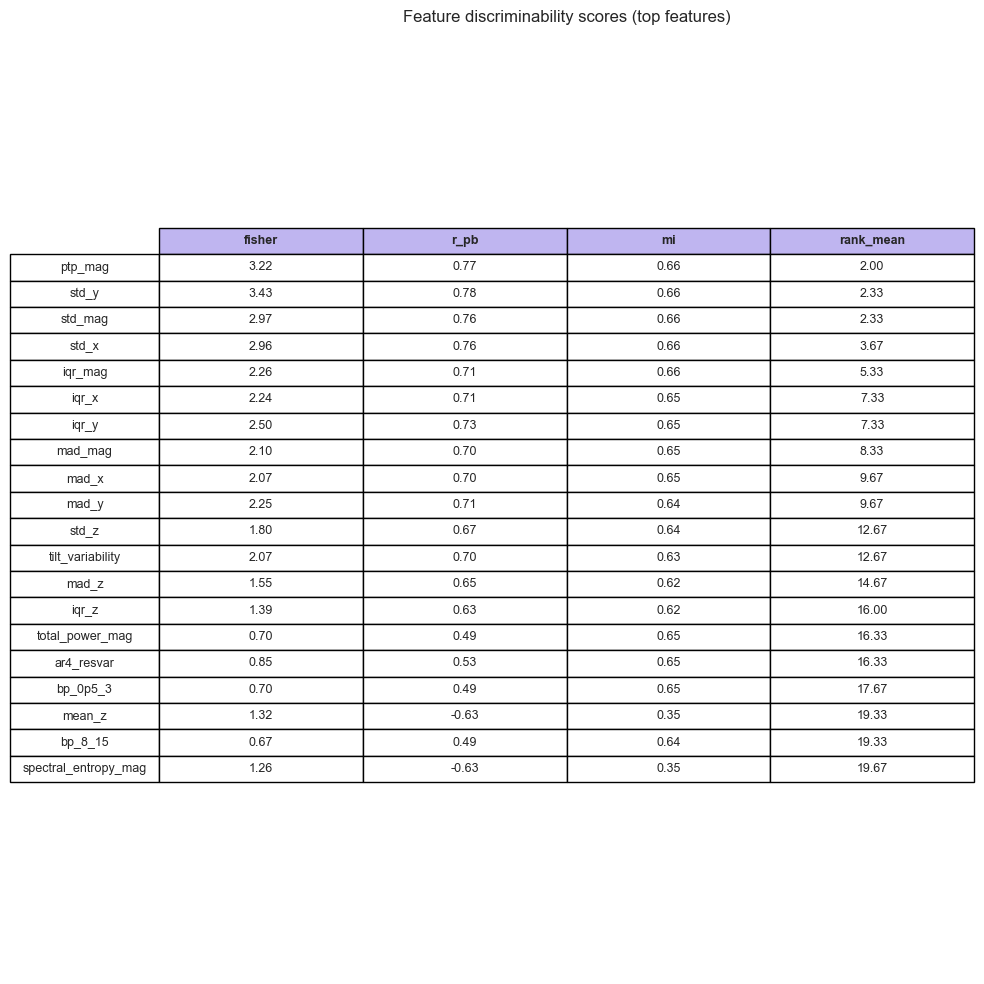

Selected features: ['ptp_mag', 'std_y', 'std_z', 'total_power_mag']


C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:582: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:582: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:582: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:582: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local

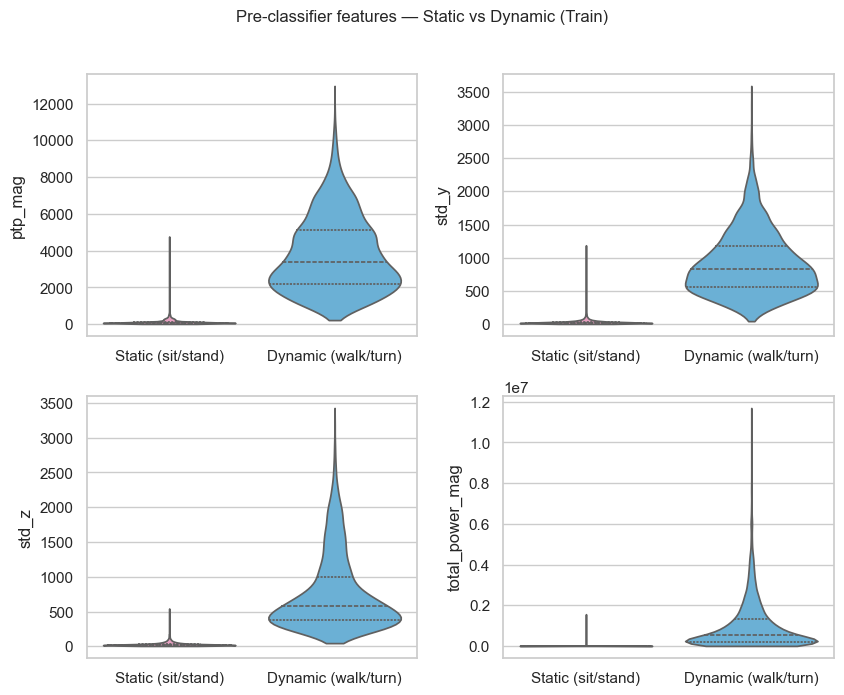

In [ ]:
# (1) FILTER USING DISCRIMINABILITY
def plot_discriminability_table(
    disc_df: pd.DataFrame,
    top_k: int = 20,
    figsize=None,
    title: str = "Feature discriminability scores (top features)",
):
    """
    Render the discriminability table as a figure with numeric values.
    Shows, for top_k features by rank_mean:
      - fisher
      - r_pb
      - mi
      - rank_mean
    """
    top_k = min(top_k, len(disc_df))
    # Take top_k best features
    df_plot = disc_df.head(top_k).copy()

    # We usually want to show the "best" at the top in the table
    cols_to_show = ["fisher", "r_pb", "mi", "rank_mean"]
    df_show = df_plot[cols_to_show].copy()

    df_show_fmt = df_show.copy()
    for c in cols_to_show:
        df_show_fmt[c] = df_show[c].map(lambda v: f"{v:.2f}")

    # Feature names as row labels
    row_labels = df_show_fmt.index.tolist()
    cell_text = df_show_fmt.values

    if figsize is None:
        figsize = (10, 0.4 * top_k + 2)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=cols_to_show,
        loc="center",
        cellLoc="center",
        rowLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.3) 

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
        # You can also tweak header background if you want:
        if row == 0:
             cell.set_facecolor("#bfb5f0")

    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

    
def discriminability_table(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    random_state: int = SEED
) -> pd.DataFrame:
    """
    Build a table of discriminability metrics:
      - Fisher score
      - point-biserial correlation
      - mutual information
    and a combined rank (lower is better).
    """
    # *** HARD CAST TO FLOAT ***
    Xf = np.asarray(Xf, dtype=float)
    y = np.asarray(y)

    # (1) Fisher scores (use helper function from before)
    fs = fisher_scores(Xf, y, colnames)   # index = feature name

    # (2) Point-biserial (use helper function from before)
    pb = point_biserial_table(Xf, y, colnames).set_index("feature")

    # (3) Mutual information
    mi = mutual_info_classif(Xf, y, random_state=random_state)
    mi_ser = pd.Series(mi, index=colnames, name="mi")

    # Assemble into one table, indexed by feature name
    df = pd.DataFrame(index=colnames)
    df["fisher"] = fs.reindex(colnames)
    df["r_pb"]   = pb["r_pb"].reindex(colnames)
    df["mi"]     = mi_ser

    # Ranks (higher score = more discriminative → lower rank value)
    df["rank_fisher"]   = df["fisher"].rank(ascending=False)
    df["rank_abs_r_pb"] = df["r_pb"].abs().rank(ascending=False)
    df["rank_mi"]       = df["mi"].rank(ascending=False)

    df["rank_mean"] = df[["rank_fisher", "rank_abs_r_pb", "rank_mi"]].mean(axis=1)

    # Sort by combined rank (best at top)
    df = df.sort_values("rank_mean")
    plot_discriminability_table(df)

    return df


# (2) CORRELATION FILTER (REMOVE REDUNDANCIES)
def corr_prune_from_rank(
    Xf: np.ndarray,
    colnames: List[str],
    ranked_features: List[str],
    corr_thr: float = 0.8,
    max_candidates: Optional[int] = None,
) -> Tuple[List[str], List[int]]:
    """
    Correlation pruning:
    - ranked_features: feature names in priority order (best → worst)
    - keep a feature only if |rho| with all already-kept features < corr_thr.
    - stop after max_candidates if given.
    """
    name_to_idx = {name: i for i, name in enumerate(colnames)}

    selected_names: List[str] = []
    selected_idx: List[int] = []

    for name in ranked_features:
        idx = name_to_idx[name]

        if not selected_idx:
            selected_names.append(name)
            selected_idx.append(idx)
        else:
            corrs = [np.corrcoef(Xf[:, idx], Xf[:, j])[0, 1] for j in selected_idx]
            if np.max(np.abs(corrs)) < corr_thr:
                selected_names.append(name)
                selected_idx.append(idx)

        if max_candidates is not None and len(selected_names) >= max_candidates:
            break

    return selected_names, selected_idx


# (3) SMALL WRAPPER FUNCTION ON TRAINING DATA ONLY TO SELECT 5 BEST FEATURES
def sfs_wrapper_svm(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    candidate_names: List[str],
    max_features: int = 20,
    C: float = 4.0,
    gamma: str = "scale",
    cv_folds: int = 3,
    random_state: int = SEED, 
) -> Tuple[List[str], List[int]]:
    """
    Very small forward selection (SFS) on top of pruned candidates.
    Returns selected feature names and indices (w.r.t. colnames).
    """
    y = np.asarray(y)
    name_to_idx = {name: i for i, name in enumerate(colnames)} # map from feature name -> column index in Xf
    candidate_idx = [name_to_idx[n] for n in candidate_names] # convert feature candidate_names into their column indices 

    selected: List[int] = [] # will store the indices of ftr cols we pick as we go
    remaining = candidate_idx.copy() # ftr indices we haven't checked yet

    # stratifiedKFold splits the data into 'cv_folds' parts with roughly the same class proportions as the full dataset
    cv = StratifiedKFold(n_splits=max(2, cv_folds), shuffle=True, random_state=random_state) # at least 2 folds

    # forward selection loop until we have 5 features
    while remaining and len(selected) < max_features:
        best_j = None
        best_score = -np.inf # init

        for j in remaining:
            cols = selected + [j]
            X_sub = Xf[:, cols]
            clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=random_state) # kernel svm
            # train 'clf' on (cv_folds -1), test on the remaining fold; repeat for each fold; return an array of accuracies (one per fold)
            scores = cross_val_score(clf, X_sub, y, cv=cv)
            score = scores.mean() # take the mean accuracy across all folds

            # keep track of best candidate this round
            if score > best_score:
                best_score = score
                best_j = j

        selected.append(best_j)
        remaining.remove(best_j)

    sel_names = [colnames[i] for i in selected]
    return sel_names, selected


# COMBINE 3 STEPS FOR FEATURE SELECTION PIPELINE
def select_features_pipeline(
    Xf_tr: np.ndarray,
    y_tr: np.ndarray,
    feat_names: List[str],
    fisher_top_k: int = 9,
    corr_thr: float = 0.8,
    max_features: int = 5,
    use_wrapper: bool = True,
) -> Tuple[List[str], List[int], pd.DataFrame]:
    """
    3-step feature selection on TRAIN features only:

    1) Filter: discriminability (Fisher + |r_pb| + MI)
    2) Corr prune: remove redundancy with |rho| > corr_thr.
    3) (optional) small wrapper (SFS with SVM) on pruned set

    Returns:
      selected_names, selected_indices, disc_table (full discriminability DataFrame)
    """
    # 1) Discriminability filter
    disc_df = discriminability_table(Xf_tr, y_tr, feat_names)
    ranked_feats = disc_df.index.tolist()
    top_feats = ranked_feats[:min(fisher_top_k, len(ranked_feats))]

    # 2) Correlation pruning
    pruned_names, pruned_idx = corr_prune_from_rank(
        Xf_tr, feat_names, top_feats,
        corr_thr=corr_thr,
        max_candidates=None
    )

    if not use_wrapper:
        # Just take the first max_features after pruning
        final_names = pruned_names[:max_features]
        final_idx = [feat_names.index(n) for n in final_names]
        return final_names, final_idx, disc_df

    # 3) Small wrapper (SFS) over the pruned set
    final_names, final_idx = sfs_wrapper_svm(
        Xf_tr, y_tr,
        feat_names,
        candidate_names=pruned_names,
        max_features=max_features,
    )

    return final_names, final_idx, disc_df

# FEATURE SELECTION ON TRAIN ONLY
sel_names, sel_idx, disc_df = select_features_pipeline(
    Xf_tr, y_int_tr, feat_names,
    fisher_top_k=15,
    corr_thr=0.85,
    max_features=20,
    use_wrapper=True
)

print("Selected features:", sel_names)

# Reduce train/val/test to selected columns = TRAINING SET
Xf_tr_sel = Xf_tr[:, sel_idx]
Xf_val_sel = Xf_val[:, sel_idx]
Xf_te_sel  = Xf_te[:,  sel_idx]

# Grid of all selected intensity features
plot_intensity_features_grid(
    Xf_tr_sel,
    y_4class=yf_tr,
    colnames=sel_names,
    features=sel_names,
    kind="violin",
    ncols=2,
    suptitle="Pre-classifier features — Static vs Dynamic (Train)",
)

## 3.4. Feature Selection for Static and Dynamic SVMs
- Now we need to choose the best features that discriminate sit vs stand and walk vs turn, as opposed to the previous dynamic vs static.
- Essentially we will make a wrapper to filter Xf_tr/yf_tr down to the two classes we care about in either case -> convert to binary labels and use existing select_features_pipeline unchanged.

In [ ]:
# =============== FEATURE SELECTION FOR PAIRWISE SVMs ==================

def _subset_pair_binary(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    feat_names: list[str],
    pos_ids: set[int],
    neg_ids: set[int],
    pos_label_name: str,
    neg_label_name: str,
):
    """
    Restrict (Xf, y_4class) to a binary pair of classes.

    pos_ids: set of 4-class IDs to map to 1 (e.g. {walk_id})
    neg_ids: set of 4-class IDs to map to 0 (e.g. {turn_id})
    """
    y_4class = np.asarray(y_4class)

    # keep only samples from the two classes of interest
    mask = np.isin(y_4class, list(pos_ids | neg_ids))
    X_pair = Xf[mask].astype(float)
    y_pair_4 = y_4class[mask]

    # map to 0/1
    y_bin = np.where(np.isin(y_pair_4, list(pos_ids)), 1, 0)

    print(f"[PAIR] {neg_label_name}=0 vs {pos_label_name}=1")
    print("  counts:", {int(k): int(v) for k, v in zip(*np.unique(y_bin, return_counts=True))})

    return X_pair, y_bin, mask


def select_features_for_pairwise_svm(
    Xf_tr: np.ndarray,
    yf_tr_4class: np.ndarray,
    feat_names: list[str],
    pos_ids: set[int],
    neg_ids: set[int],
    pos_label_name: str,
    neg_label_name: str,
    fisher_top_k: int = 10,
    corr_thr: float = 0.85,
    max_features: int = 5,
    use_wrapper: bool = True,
):
    """
    Convenience wrapper:

      1) Restrict TRAIN windows to the two target activities.
      2) Map them to binary labels (0/1).
      3) Run existing select_features_pipeline on that binary subset.

    Returns
    -------
    sel_names : list[str]              # selected feature names
    sel_idx   : list[int]              # indices into feat_names (global columns)
    disc_df   : pd.DataFrame           # discriminability table (for the pair)
    mask_tr   : np.ndarray[bool]       # which training windows were kept
    y_bin_tr  : np.ndarray[int]        # 0/1 labels corresponding to Xf_tr[mask_tr]
    """
    # 1) restrict & binarize
    X_pair_tr, y_pair_tr, mask_tr = _subset_pair_binary(
        Xf_tr,
        yf_tr_4class,
        feat_names,
        pos_ids=pos_ids,
        neg_ids=neg_ids,
        pos_label_name=pos_label_name,
        neg_label_name=neg_label_name,
    )

    # 2) run the select_features_pipeline on the binarized training set
    sel_names, sel_idx, disc_df = select_features_pipeline(
        X_pair_tr,
        y_pair_tr,
        feat_names,
        fisher_top_k=fisher_top_k,
        corr_thr=corr_thr,
        max_features=max_features,
        use_wrapper=use_wrapper,
    )

    print(f"[PAIR FS] Selected features for {neg_label_name} vs {pos_label_name}:")
    for name in sel_names:
        print("   -", name)

    return sel_names, sel_idx, disc_df, mask_tr, y_pair_tr


- Now we can select the features for static and dynamic SVM in the same way we did for the preclassifier.

[PAIR] sit=0 vs stand=1
  counts: {0: 2806, 1: 1874}


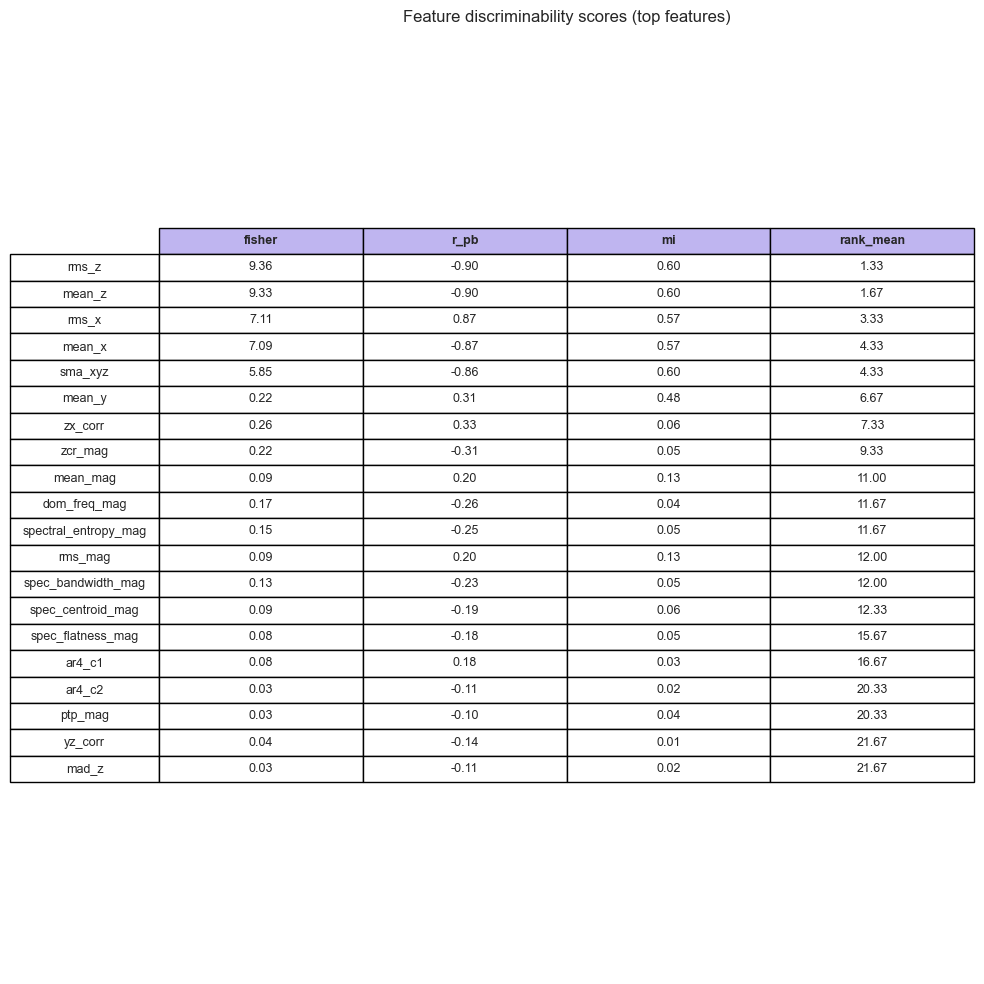

[PAIR FS] Selected features for sit vs stand:
   - sma_xyz
   - rms_z
   - mean_y
   - ptp_mag
   - zx_corr
   - zcr_mag
   - mean_mag
   - dom_freq_mag
   - spectral_entropy_mag
   - ar4_c1
   - ar4_c2
   - yz_corr
   - mad_z
   - ar4_c4
[PAIR] turn=0 vs walk=1
  counts: {0: 2320, 1: 3150}


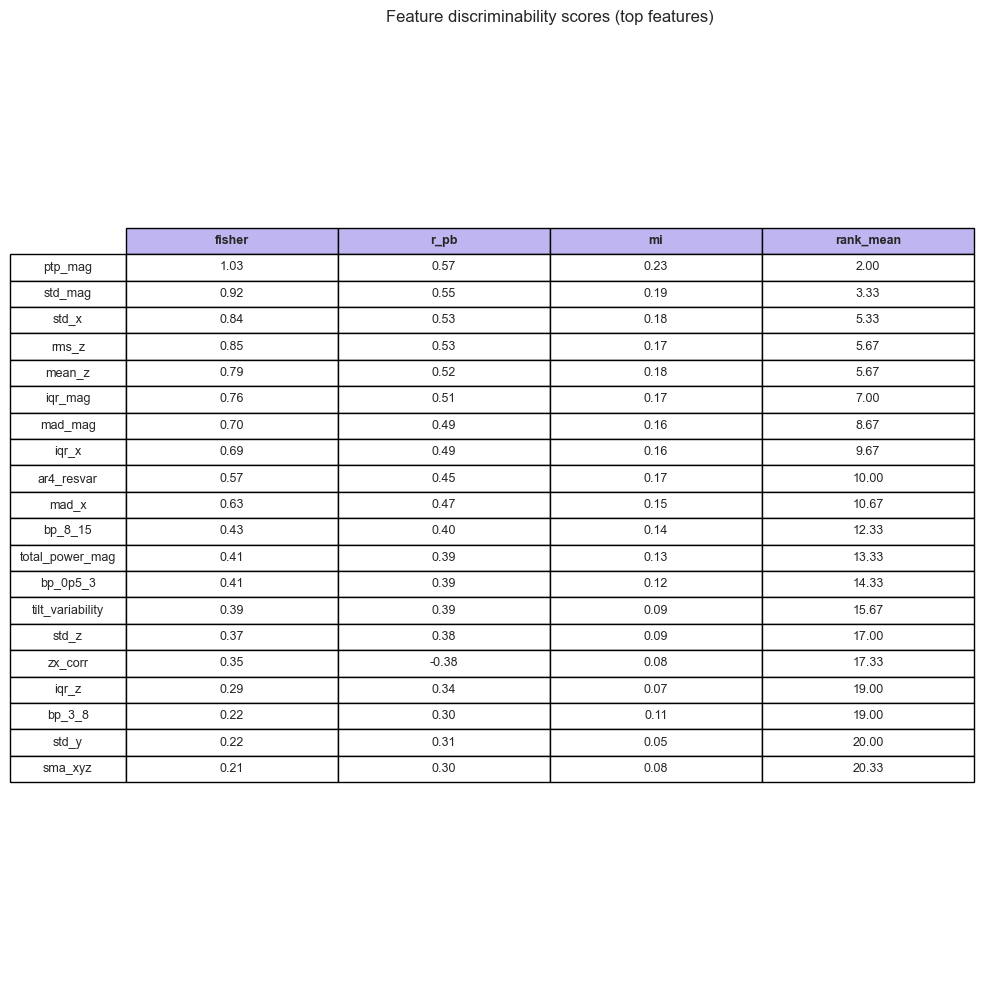

[PAIR FS] Selected features for turn vs walk:
   - ptp_mag
   - mean_z
   - sma_xyz
   - rms_z
   - mean_x
   - std_y
   - tilt_variability
   - zx_corr
   - mad_mag
   - bp_3_8
   - bp_8_15


In [ ]:
# ---------- Static SVM: sit vs stand ----------

sel_static_names, sel_static_idx, disc_static_df, mask_tr_static, y_tr_static_bin = (
    select_features_for_pairwise_svm(
        Xf_tr,
        yf_tr,
        feat_names,
        pos_ids=STATIC_PAIR_POS,
        neg_ids=STATIC_PAIR_NEG,
        pos_label_name="stand",
        neg_label_name="sit",
        fisher_top_k=23,
        corr_thr=0.85,
        max_features=20,
        use_wrapper=True,
    )
)

# Build train/val/test matrices for the static SVM using these features
mask_val_static = np.isin(yf_val, list(STATIC_PAIR_POS | STATIC_PAIR_NEG))
mask_te_static  = np.isin(yf_te,  list(STATIC_PAIR_POS | STATIC_PAIR_NEG))

X_tr_static = Xf_tr[mask_tr_static][:, sel_static_idx]
X_val_static = Xf_val[mask_val_static][:, sel_static_idx]
X_te_static  = Xf_te[mask_te_static][:,  sel_static_idx]

# Binary labels for val/test (0=sit, 1=stand)
y_val_static_bin = np.where(np.isin(yf_val[mask_val_static], list(STATIC_PAIR_POS)), 1, 0)
y_te_static_bin  = np.where(np.isin(yf_te[mask_te_static],  list(STATIC_PAIR_POS)), 1, 0)

# ---------- Dynamic SVM: walk vs turn ----------

sel_dyn_names, sel_dyn_idx, disc_dyn_df, mask_tr_dyn, y_tr_dyn_bin = (
    select_features_for_pairwise_svm(
        Xf_tr,
        yf_tr,
        feat_names,
        pos_ids=DYNAMIC_PAIR_POS,
        neg_ids=DYNAMIC_PAIR_NEG,
        pos_label_name="walk",
        neg_label_name="turn",
        fisher_top_k=23,
        corr_thr=0.85,
        max_features=20,
        use_wrapper=True,
    )
)

mask_val_dyn = np.isin(yf_val, list(DYNAMIC_PAIR_POS | DYNAMIC_PAIR_NEG))
mask_te_dyn  = np.isin(yf_te,  list(DYNAMIC_PAIR_POS | DYNAMIC_PAIR_NEG))

X_tr_dyn = Xf_tr[mask_tr_dyn][:, sel_dyn_idx]
X_val_dyn = Xf_val[mask_val_dyn][:, sel_dyn_idx]
X_te_dyn  = Xf_te[mask_te_dyn][:,  sel_dyn_idx]

# Binary labels for val/test (0=turn, 1=walk)
y_val_dyn_bin = np.where(np.isin(yf_val[mask_val_dyn], list(DYNAMIC_PAIR_POS)), 1, 0)
y_te_dyn_bin  = np.where(np.isin(yf_te[mask_te_dyn],  list(DYNAMIC_PAIR_POS)), 1, 0)



## 4. Formulate Decision Function: Build Threshold Function for Preclassifier + Train the two SVMs
- We need a function that takes in the selected features for the preclassifier and returns static or dynamic. We will use logistic regression for this.
- We need to tune hyperparameters (c, gamma) using a simple manual grid search
- Complete SVM training on training set
- Use val set for hyperparam tuning

## 4.1. Preclassifier

In [ ]:
# Train intensity pre-classifier on TRAIN (selected features only)
def train_intensity_preclassifier(
    X_tr_sel: np.ndarray,
    y_int_tr: np.ndarray,
    random_state: int = SEED,
) -> Pipeline:
    """
    Small linear pre-classifier:
      - StandardScaler
      - LogisticRegression (binary: 0=static, 1=dynamic)
    """
    y_int_tr = np.asarray(y_int_tr)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state,
        )),
    ])

    pipe.fit(X_tr_sel, y_int_tr)
    return pipe

# train it
intensity_clf = train_intensity_preclassifier(Xf_tr_sel, y_int_tr, random_state=SEED)

## 4.2. SVMs

In [ ]:
def tune_svm_hyperparams(
    X: np.ndarray,
    y: np.ndarray,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds: int = 5,
    random_state: int = SEED,
) -> Tuple[float, str, pd.DataFrame]:
    """
    Hyperparameter tuning on TRAIN with 5-fold cross-validation to get initial best candidates
    *Scaling is included inside the sklearn pipeline.

    Returns
    -------
    best_C : float
    best_gamma : str or float
    results_df : pd.DataFrame with columns [C, gamma, mean_acc, std_acc]
    """
    y = np.asarray(y)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    rows = []
    best_score = -np.inf
    best_C = None
    best_gamma = None

    # Grid search
    for C in C_grid:
        for gamma in gamma_grid:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(
                    kernel="rbf",
                    C=C,
                    gamma=gamma,
                    class_weight="balanced",
                    random_state=random_state,
                )),
            ])

            scores = cross_val_score(pipe, X, y, cv=cv)
            mean_acc = scores.mean()
            std_acc = scores.std()

            rows.append({
                "C": C,
                "gamma": gamma,
                "mean_acc": mean_acc,
                "std_acc": std_acc,
            })

            # keep track of current best in search
            if mean_acc > best_score:
                best_score = mean_acc
                best_C = C
                best_gamma = gamma

    results_df = pd.DataFrame(rows).sort_values("mean_acc", ascending=False).reset_index(drop=True)
    return best_C, best_gamma, results_df

# Final training SVM helper with the best hyperparams
def train_svm_rbf(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    C: float,
    gamma,
    random_state: int = SEED,
) -> Pipeline:
    """
    Train a final RBF SVM (with scaling) on the given training data
    using the supplied hyperparameters.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight="balanced",
            probability=True, 
            random_state=random_state,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe


,C,gamma,mean_acc,std_acc
0,4.0,0.01,0.999573,0.000523
1,8.0,0.01,0.999573,0.000523
2,2.0,0.01,0.999359,0.000523
3,1.0,0.01,0.999145,0.000799
4,0.5,0.01,0.998932,0.001170


[STATIC] (C=4.0, gamma=0.01) -> Val Acc = 1.0000
[STATIC] (C=8.0, gamma=0.01) -> Val Acc = 1.0000
[STATIC] (C=2.0, gamma=0.01) -> Val Acc = 1.0000
[STATIC] (C=1.0, gamma=0.01) -> Val Acc = 1.0000
[STATIC] (C=0.5, gamma=0.01) -> Val Acc = 1.0000
[STATIC] (C=2.0, gamma=scale) -> Val Acc = 1.0000

[STATIC] Final hyperparameters based on VAL:
  C_final     = 4.0
  gamma_final = 0.01
  Val accuracy= 1.0000
[STATIC] Test accuracy = 1.0000


C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed

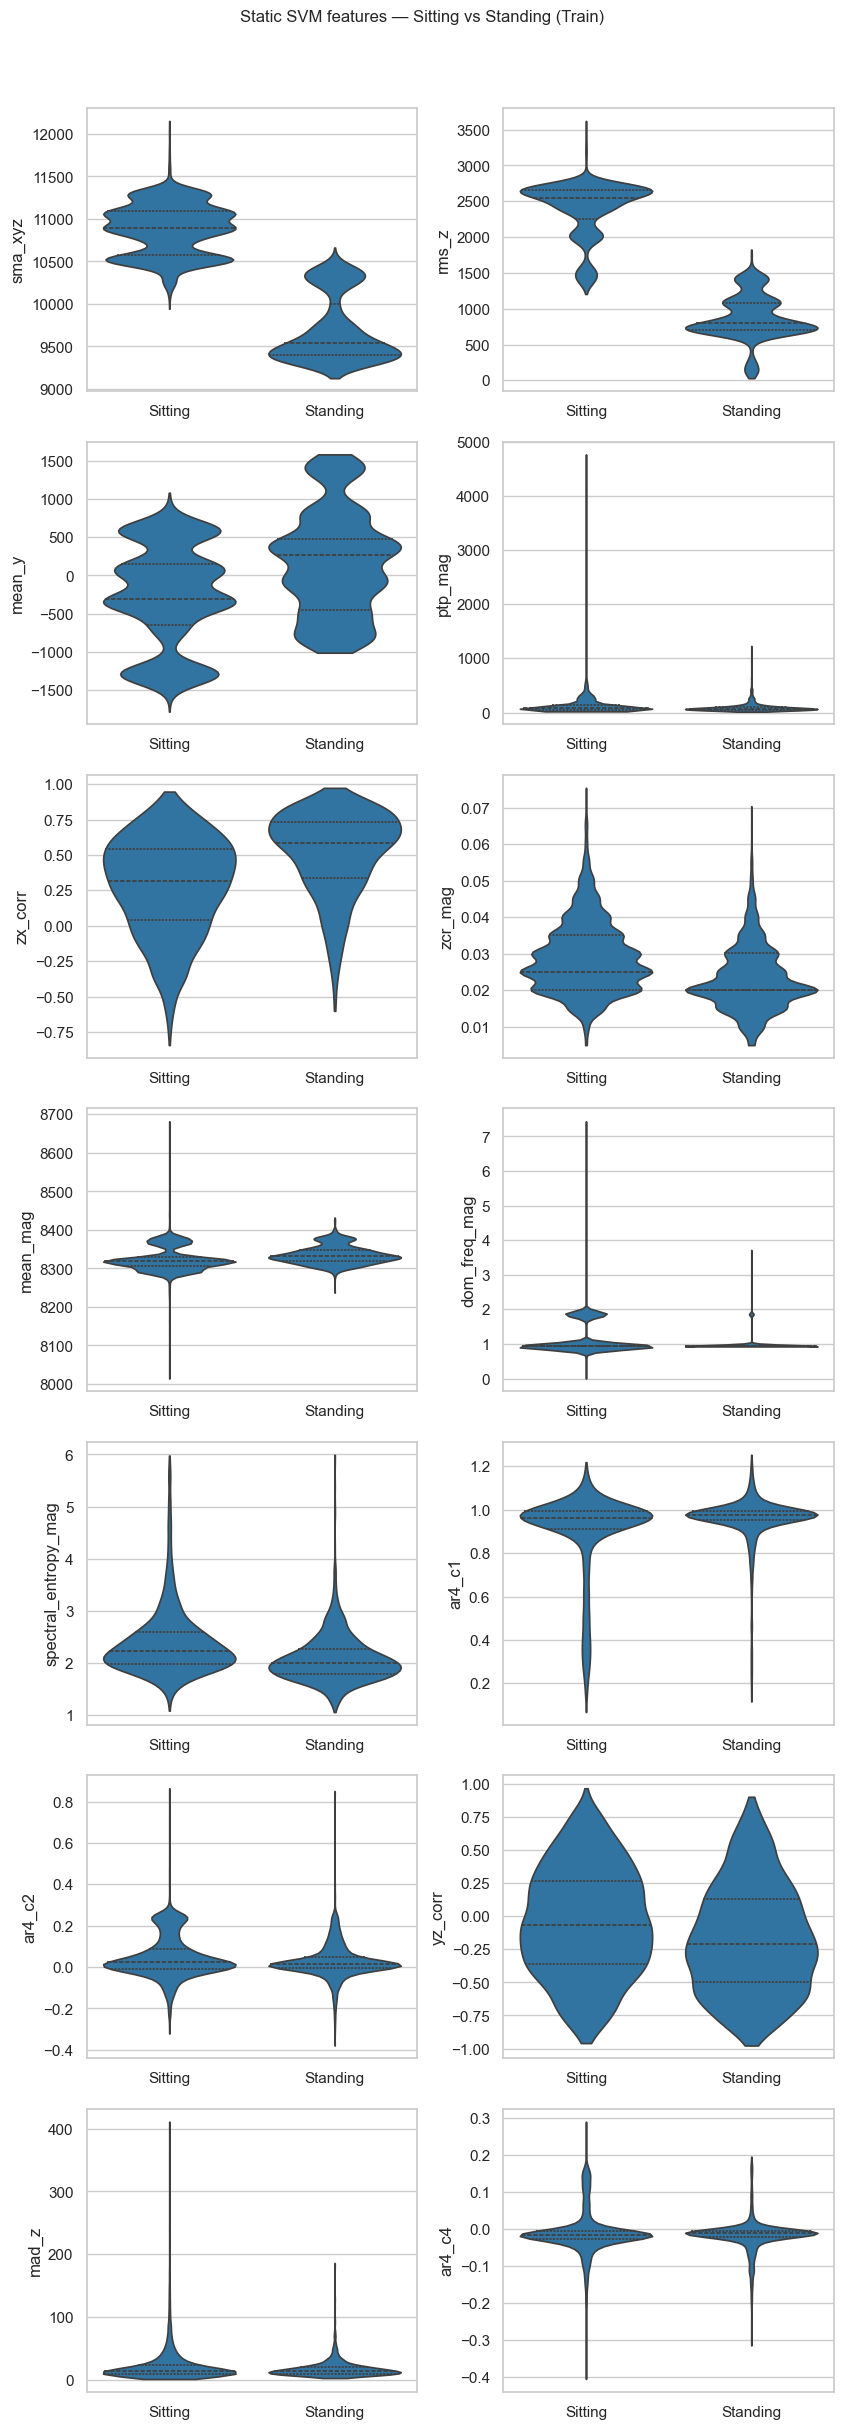

,C,gamma,mean_acc,std_acc
0,8.0,0.1,0.920841,0.009422
1,4.0,0.1,0.920658,0.008907
2,8.0,scale,0.920293,0.009869
3,4.0,scale,0.919927,0.008229
4,2.0,0.1,0.919561,0.007426


[DYN] (C=8.0, gamma=0.1) -> Val Acc = 0.9204
[DYN] (C=4.0, gamma=0.1) -> Val Acc = 0.9174
[DYN] (C=8.0, gamma=scale) -> Val Acc = 0.9174
[DYN] (C=4.0, gamma=scale) -> Val Acc = 0.9174
[DYN] (C=2.0, gamma=0.1) -> Val Acc = 0.9133
[DYN] (C=2.0, gamma=scale) -> Val Acc = 0.9133

[DYN] Final hyperparameters based on VAL:
  C_final     = 8.0
  gamma_final = 0.1
  Val accuracy= 0.9204
[DYN] Test accuracy = 0.9168


C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\3754729.py:654: FutureWarning: 

The `scale` parameter has been renamed

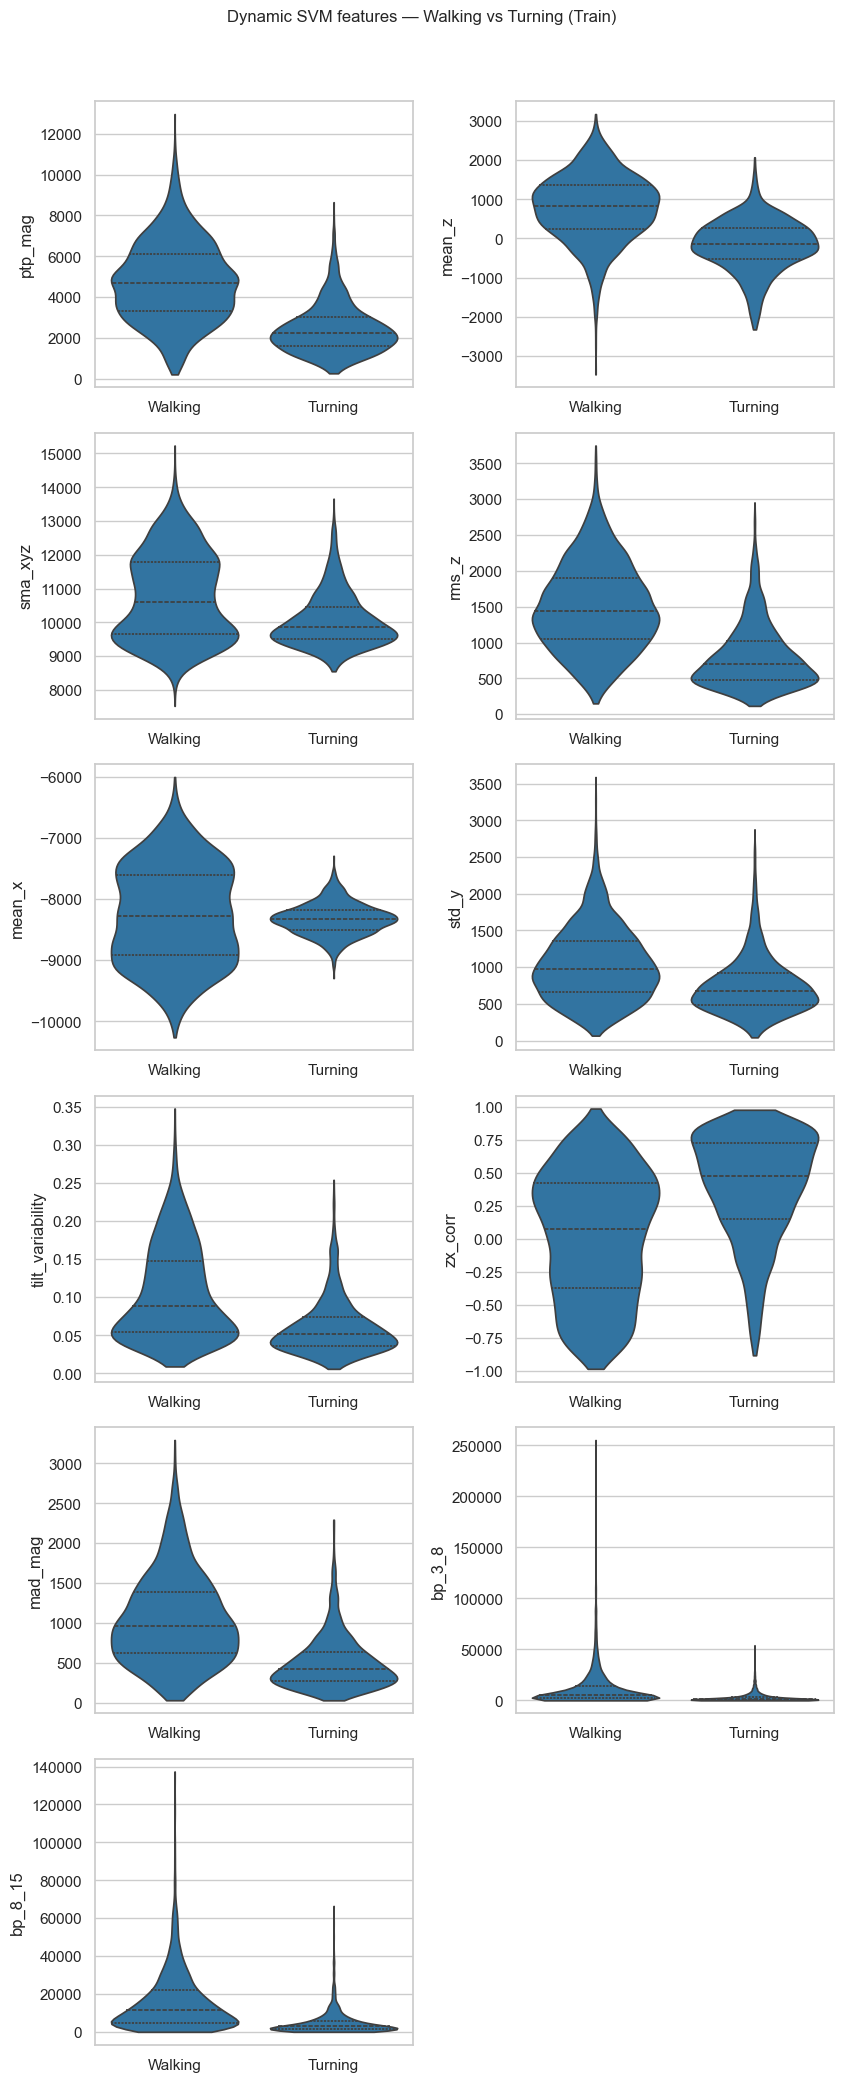

In [ ]:
# ================= STATIC SVM: hyperparameter tuning =================

best_C_cv_static, best_gamma_cv_static, cv_table_static = tune_svm_hyperparams(
    X_tr_static, y_tr_static_bin,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds=5,
    random_state=SEED,
)

display(cv_table_static.head())

# shortlist the best K from CV
top_k = 6
candidates_static = cv_table_static.head(top_k)

best_val_acc_static = -np.inf
best_C_static = None
best_gamma_static = None

for _, row in candidates_static.iterrows():
    C = row["C"]
    gamma = row["gamma"]

    model = train_svm_rbf(X_tr_static, y_tr_static_bin, C=C, gamma=gamma, random_state=SEED)

    y_val_pred = model.predict(X_val_static)
    val_acc = accuracy_score(y_val_static_bin, y_val_pred)

    print(f"[STATIC] (C={C}, gamma={gamma}) -> Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc_static:
        best_val_acc_static = val_acc
        best_C_static = C
        best_gamma_static = gamma

print("\n[STATIC] Final hyperparameters based on VAL:")
print(f"  C_final     = {best_C_static}")
print(f"  gamma_final = {best_gamma_static}")
print(f"  Val accuracy= {best_val_acc_static:.4f}")

# final static SVM
static_svm = train_svm_rbf(X_tr_static, y_tr_static_bin,
                           C=best_C_static, gamma=best_gamma_static, random_state=SEED)

y_te_pred_static = static_svm.predict(X_te_static)
test_acc_static = accuracy_score(y_te_static_bin, y_te_pred_static)
print(f"[STATIC] Test accuracy = {test_acc_static:.4f}")

# Build the pairwise train matrix (only static windows, only selected features)
X_tr_static = Xf_tr[mask_tr_static][:, sel_static_idx]
y_tr_static_4class = yf_tr[mask_tr_static]

# Violin plots for STATIC SVM selected features
plot_pair_features_grid(
    X_pair=X_tr_static,
    y_pair_4class=y_tr_static_4class,
    colnames=sel_static_names,   # names for the selected columns
    features=sel_static_names,   # plot all selected features
    kind="violin",
    ncols=2,
    suptitle="Static SVM features — Sitting vs Standing (Train)",
)


# ================= DYNAMIC SVM: hyperparameter tuning =================

best_C_cv_dyn, best_gamma_cv_dyn, cv_table_dyn = tune_svm_hyperparams(
    X_tr_dyn, y_tr_dyn_bin,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds=5,
    random_state=SEED,
)

display(cv_table_dyn.head())

candidates_dyn = cv_table_dyn.head(top_k)

best_val_acc_dyn = -np.inf
best_C_dyn = None
best_gamma_dyn = None

for _, row in candidates_dyn.iterrows():
    C = row["C"]
    gamma = row["gamma"]

    model = train_svm_rbf(X_tr_dyn, y_tr_dyn_bin, C=C, gamma=gamma, random_state=SEED)

    y_val_pred = model.predict(X_val_dyn)
    val_acc = accuracy_score(y_val_dyn_bin, y_val_pred)

    print(f"[DYN] (C={C}, gamma={gamma}) -> Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc_dyn:
        best_val_acc_dyn = val_acc
        best_C_dyn = C
        best_gamma_dyn = gamma

print("\n[DYN] Final hyperparameters based on VAL:")
print(f"  C_final     = {best_C_dyn}")
print(f"  gamma_final = {best_gamma_dyn}")
print(f"  Val accuracy= {best_val_acc_dyn:.4f}")

# final dynamic SVM
dyn_svm = train_svm_rbf(X_tr_dyn, y_tr_dyn_bin,
                        C=best_C_dyn, gamma=best_gamma_dyn, random_state=SEED)

y_te_pred_dyn = dyn_svm.predict(X_te_dyn)
test_acc_dyn = accuracy_score(y_te_dyn_bin, y_te_pred_dyn)
print(f"[DYN] Test accuracy = {test_acc_dyn:.4f}")

# Build the pairwise train matrix (only dynamic windows, only selected features)
X_tr_dyn = Xf_tr[mask_tr_dyn][:, sel_dyn_idx]
y_tr_dyn_4class = yf_tr[mask_tr_dyn]  # still 0..3, but only walk/turn here

# Violin plots for DYNAMIC SVM selected features
plot_pair_features_grid(
    X_pair=X_tr_dyn,
    y_pair_4class=y_tr_dyn_4class,
    colnames=sel_dyn_names,
    features=sel_dyn_names,
    kind="violin",
    ncols=2,
    suptitle="Dynamic SVM features — Walking vs Turning (Train)",
)





## 4.3. Build (final) hiearchical preclassifier + 2 SVM model to separate the four classes.

In [ ]:
# 1) callable wrapper for preclassifier prediction fn
def intensity_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    X_full: feature matrix with columns in the order of `feat_names`.
    Uses `sel_idx` and `intensity_clf` to output 0/1 (static/dynamic).
    """
    X_full = np.asarray(X_full, dtype=float)
    X_sel = X_full[:, sel_idx]
    return intensity_clf.predict(X_sel).astype(int)

# 2) wrappers for dynamic and static svm prediction fns
STATIC_SEL_IDX = sel_static_idx   
DYN_SEL_IDX    = sel_dyn_idx

def static_branch_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    Predict within the static branch: 0 = stand, 1 = sit
    """
    X_full = np.asarray(X_full, dtype=float)
    X_static = X_full[:, STATIC_SEL_IDX]
    return static_svm.predict(X_static)

def dynamic_branch_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    Predict within the dynamic branch: 0 = walk, 1 = turn
    """
    X_full = np.asarray(X_full, dtype=float)
    X_dyn = X_full[:, DYN_SEL_IDX]
    return dyn_svm.predict(X_dyn)

# 3) put it all together for final decision fn
def hierarchical_predict_4class(X_full: np.ndarray) -> np.ndarray:
    X_full = np.asarray(X_full, dtype=float)
    N = X_full.shape[0]

    # 1) Intensity (0=static, 1=dynamic)
    y_int = intensity_predict_fn(X_full).astype(int).ravel()

    y_out = np.empty(N, dtype=int)

    # 2) Static branch: 1=Stand, 0=Sit
    mask_static = (y_int == 0)
    if np.any(mask_static):
        X_static = X_full[mask_static][:, STATIC_SEL_IDX]
        y_static_bin = static_svm.predict(X_static).astype(int).ravel()
        # 1 -> STAND_ID, 0 -> SIT_ID
        y_out[mask_static] = np.where(y_static_bin == 1, STAND_ID, SIT_ID)

    # 3) Dynamic branch: 1=Walk, 0=Turn
    mask_dyn = (y_int == 1)
    if np.any(mask_dyn):
        X_dyn = X_full[mask_dyn][:, DYN_SEL_IDX]
        y_dyn_bin = dyn_svm.predict(X_dyn).astype(int).ravel()
        # 1 -> WALK_ID, 0 -> TURN_ID
        y_out[mask_dyn] = np.where(y_dyn_bin == 1, WALK_ID, TURN_ID)

    return y_out



# 5. Measure Performance
- Now we can use the test set to measure performance.

In [ ]:
def evaluate_model(
    X: np.ndarray,
    y: np.ndarray,
    split_name: str,
    predict_fn: Callable[[np.ndarray], np.ndarray],
    label_id_to_display: Dict[int, str],
    class_labels: Optional[Sequence[int]] = None,
    average: str = "macro",
    plot_cm: bool = True,
) -> Dict[str, float]:
    """
    Generic evaluation helper for *any* predictor function.

    - predict_fn(X) must return either:
        * 1D array of label IDs, or
        * 2D probs/logits (N, C), or
        * a tuple (y_pred, extra)
    - y: true label IDs (ints).
    """

    # --- Clean up y_true ---
    y_true = np.asarray(y)
    if y_true.ndim != 1:
        y_true = y_true.ravel()
    y_true = y_true.astype(int)

    # --- Call predictor and normalize output ---
    raw_pred = predict_fn(X)

    # handle tuple output (e.g. (y_pred, probs))
    if isinstance(raw_pred, tuple):
        y_pred = raw_pred[0]
    else:
        y_pred = raw_pred

    y_pred = np.asarray(y_pred)

    # if probabilities/logits or column vector
    if y_pred.ndim == 2:
        if y_pred.shape[1] == 1:
            y_pred = y_pred.ravel()
        else:
            # assume class scores → take argmax
            y_pred = np.argmax(y_pred, axis=1)

    if y_pred.ndim != 1:
        raise ValueError(f"predict_fn must return 1D labels or (N,C) scores; got shape {y_pred.shape}")

    y_pred = y_pred.astype(int)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Length mismatch: y_true={y_true.shape[0]}, y_pred={y_pred.shape[0]}")

    # --- Class labels for metrics / confusion matrix ---
    if class_labels is None:
        class_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))

    # --- Metrics ---
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        average=average,
        zero_division=0,
    )

    print(f"\n=== {split_name} metrics ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # --- Confusion matrix ---
    if plot_cm:
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        display_labels = [label_id_to_display[c] for c in class_labels]

        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        disp.plot(cmap="Blues")
        plt.title(f"{split_name} — Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

Test preclassifier:


=== Intensity - Train metrics ===
Accuracy : 0.9904
Precision: 0.9948
Recall   : 0.9874
F1-score : 0.9911


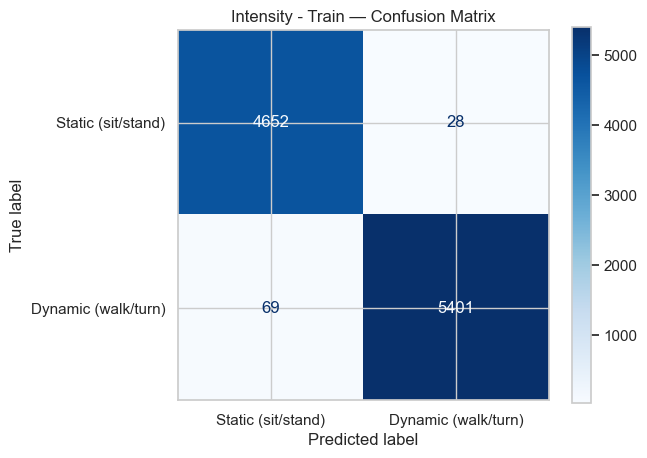


=== Intensity - Validation metrics ===
Accuracy : 0.9914
Precision: 0.9958
Recall   : 0.9881
F1-score : 0.9919


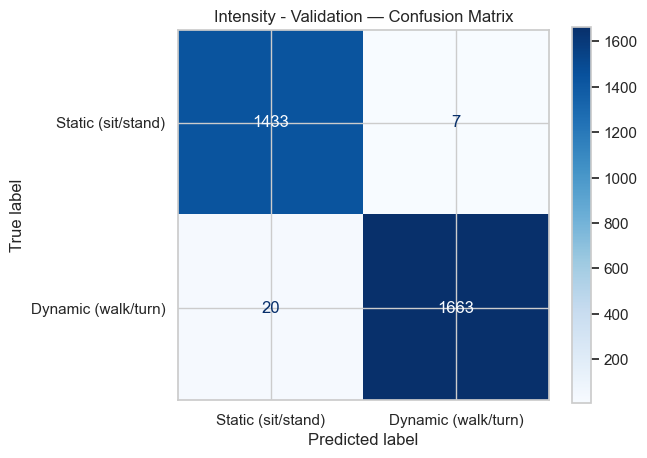


=== Intensity - Test metrics ===
Accuracy : 0.9902
Precision: 0.9944
Recall   : 0.9873
F1-score : 0.9909


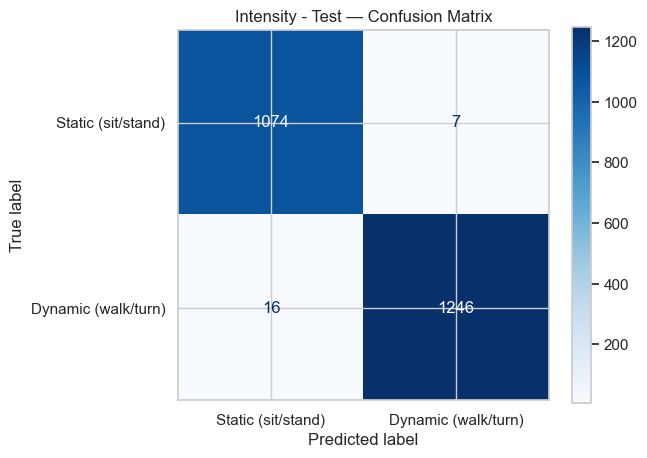

In [ ]:
metrics_int_tr = evaluate_model(
    X=Xf_tr,
    y=y_int_tr,
    split_name="Intensity - Train",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],      # to force order Static, Dynamic
    average="binary",
)

metrics_int_val = evaluate_model(
    X=Xf_val,
    y=y_int_val,
    split_name="Intensity - Validation",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_int_te = evaluate_model(
    X=Xf_te,
    y=y_int_te,
    split_name="Intensity - Test",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],
    average="binary",
)



Test SVMs


=== Static SVM – Train (Stand vs Sit) metrics ===
Accuracy : 0.9996
Precision: 1.0000
Recall   : 0.9989
F1-score : 0.9995


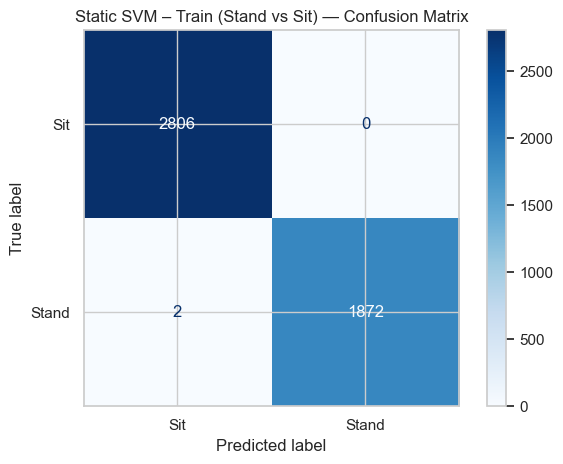


=== Static SVM – Validation (Stand vs Sit) metrics ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


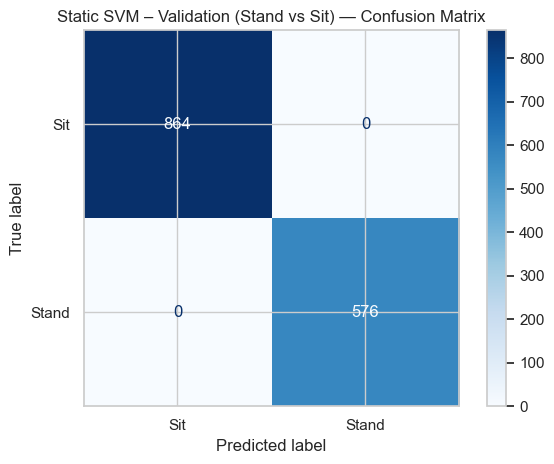


=== Static SVM – Test (Stand vs Sit) metrics ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


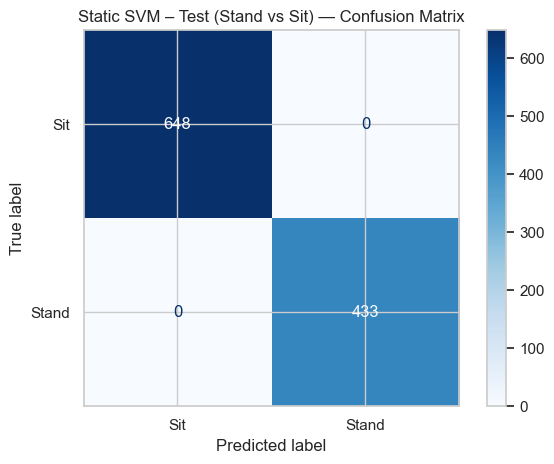


=== Dynamic SVM – Train (Walk vs Turn) metrics ===
Accuracy : 0.9378
Precision: 0.9828
Recall   : 0.9079
F1-score : 0.9439


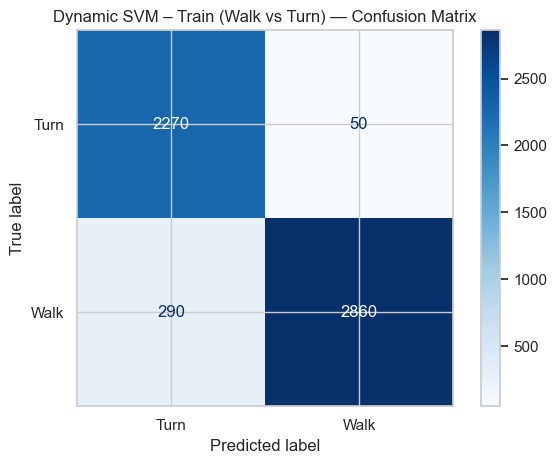


=== Dynamic SVM – Validation (Walk vs Turn) metrics ===
Accuracy : 0.9204
Precision: 0.9623
Recall   : 0.8968
F1-score : 0.9284


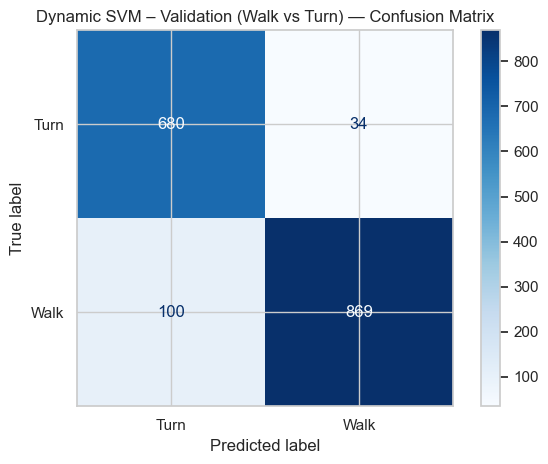


=== Dynamic SVM – Test (Walk vs Turn) metrics ===
Accuracy : 0.9168
Precision: 0.9628
Recall   : 0.8900
F1-score : 0.9249


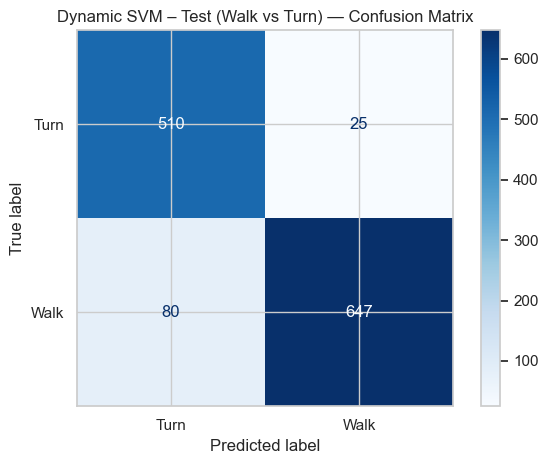

In [ ]:
# ---------- STATIC SVM: evaluation ----------

def static_predict_fn(X: np.ndarray) -> np.ndarray:
    """Wrapper so we can use evaluate_model with the static SVM pipeline."""
    return static_svm.predict(X)

metrics_static_tr = evaluate_model(
    X=X_tr_static,
    y=y_tr_static_bin,
    split_name="Static SVM – Train (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],     # 0=Stand, 1=Sit
    average="binary",
)

metrics_static_val = evaluate_model(
    X=X_val_static,
    y=y_val_static_bin,
    split_name="Static SVM – Validation (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_static_te = evaluate_model(
    X=X_te_static,
    y=y_te_static_bin,
    split_name="Static SVM – Test (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],
    average="binary",
)

# ---------- DYNAMIC SVM: evaluation ----------

def dyn_predict_fn(X: np.ndarray) -> np.ndarray:
    """Wrapper so we can use evaluate_model with the dynamic SVM pipeline."""
    return dyn_svm.predict(X)

metrics_dyn_tr = evaluate_model(
    X=X_tr_dyn,
    y=y_tr_dyn_bin,
    split_name="Dynamic SVM – Train (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],     # 0=Walk, 1=Turn
    average="binary",
)

metrics_dyn_val = evaluate_model(
    X=X_val_dyn,
    y=y_val_dyn_bin,
    split_name="Dynamic SVM – Validation (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_dyn_te = evaluate_model(
    X=X_te_dyn,
    y=y_te_dyn_bin,
    split_name="Dynamic SVM – Test (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],
    average="binary",
)


Test full pipeline


[DEBUG] First 20 samples — true vs hierarchical pred
i= 0  true=0 (Walk)  pred=0 (Walk)
i= 1  true=0 (Walk)  pred=0 (Walk)
i= 2  true=1 (Sit)  pred=1 (Sit)
i= 3  true=1 (Sit)  pred=1 (Sit)
i= 4  true=1 (Sit)  pred=1 (Sit)
i= 5  true=2 (Stand)  pred=2 (Stand)
i= 6  true=1 (Sit)  pred=1 (Sit)
i= 7  true=1 (Sit)  pred=1 (Sit)
i= 8  true=1 (Sit)  pred=1 (Sit)
i= 9  true=2 (Stand)  pred=2 (Stand)
i=10  true=3 (Turn)  pred=3 (Turn)
i=11  true=1 (Sit)  pred=1 (Sit)
i=12  true=2 (Stand)  pred=2 (Stand)
i=13  true=3 (Turn)  pred=3 (Turn)
i=14  true=3 (Turn)  pred=3 (Turn)
i=15  true=0 (Walk)  pred=0 (Walk)
i=16  true=1 (Sit)  pred=1 (Sit)
i=17  true=3 (Turn)  pred=3 (Turn)
i=18  true=0 (Walk)  pred=0 (Walk)
i=19  true=0 (Walk)  pred=0 (Walk)

=== Hierarchical HAR – Train metrics ===
Accuracy : 0.9592
Precision: 0.9583
Recall   : 0.9641
F1-score : 0.9605


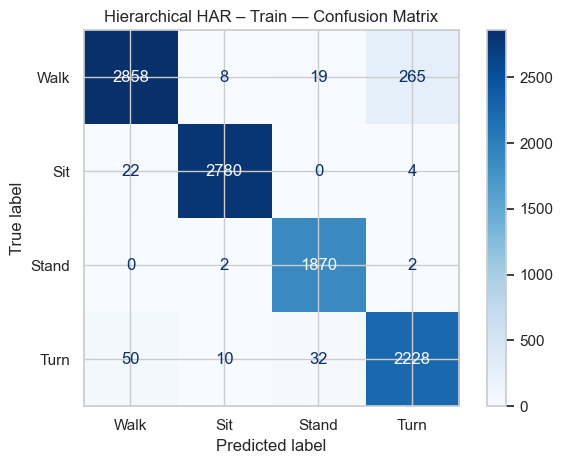


=== Hierarchical HAR – Validation metrics ===
Accuracy : 0.9513
Precision: 0.9511
Recall   : 0.9564
F1-score : 0.9532


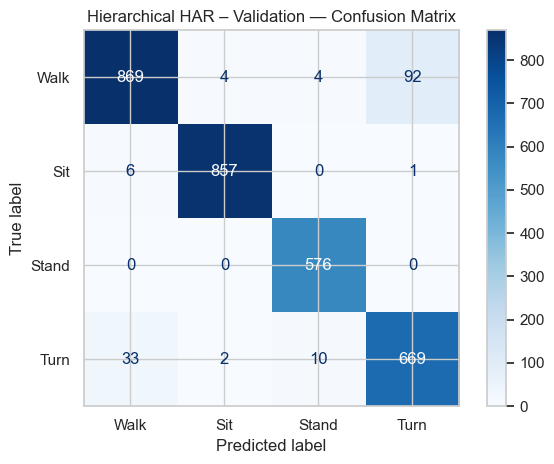


=== Hierarchical HAR – Test metrics ===
Accuracy : 0.9484
Precision: 0.9482
Recall   : 0.9538
F1-score : 0.9503


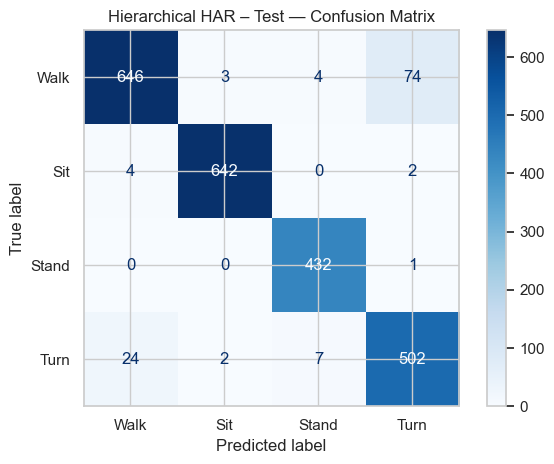

In [ ]:
LABEL_ID_TO_DISPLAY = {
    0: "Walk",
    1: "Sit",
    2: "Stand",
    3: "Turn",
}
all_class_ids = sorted(LABEL_ID_TO_DISPLAY.keys())

print("\n[DEBUG] First 20 samples — true vs hierarchical pred")
y_pred_debug = hierarchical_predict_4class(Xf_tr[:20])
for i in range(20):
    ti = int(yf_tr[i])
    pi = int(y_pred_debug[i])
    print(
        f"i={i:2d}  "
        f"true={ti} ({LABEL_ID_TO_DISPLAY.get(ti, '??')})  "
        f"pred={pi} ({LABEL_ID_TO_DISPLAY.get(pi, '??')})"
    )

metrics_h_tr = evaluate_model(
    X=Xf_tr,
    y=yf_tr,
    split_name="Hierarchical HAR – Train",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,   # [0,1,2,3]
    average="macro",
)

metrics_h_val = evaluate_model(
    X=Xf_val,
    y=yf_val,
    split_name="Hierarchical HAR – Validation",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,
    average="macro",
)

metrics_h_te = evaluate_model(
    X=Xf_te,
    y=yf_te,
    split_name="Hierarchical HAR – Test",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,
    average="macro",
)



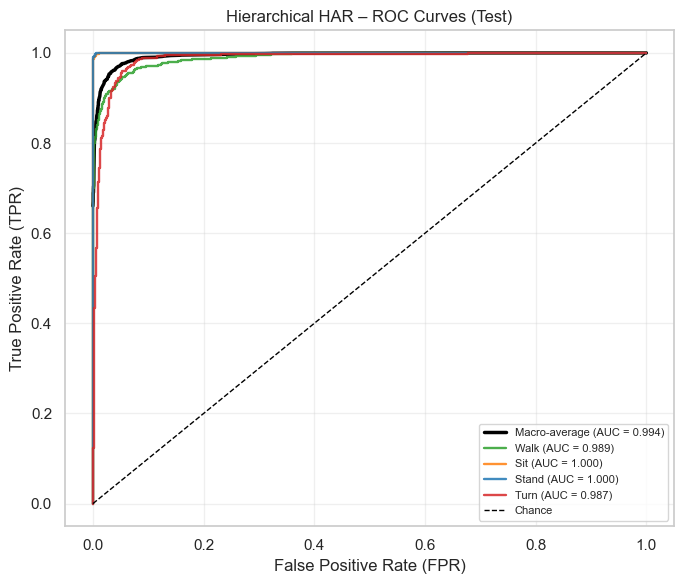


[ROC DEBUG] Approx TPR/FPR at threshold ~0.5 for split: Test
  0 (Walk): FPR ≈ 0.022, TPR ≈ 0.905, thr ≈ 0.500
  1 (Sit): FPR ≈ 0.002, TPR ≈ 0.991, thr ≈ 0.608
  2 (Stand): FPR ≈ 0.006, TPR ≈ 0.998, thr ≈ 0.462
  3 (Turn): FPR ≈ 0.036, TPR ≈ 0.918, thr ≈ 0.500


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

INACTIVE_ID = 4  # for reference only, we filter it out

# -------------------------------------------------------------------
# Helper: get binary P(y = positive_label | x) from a sklearn classifier
# -------------------------------------------------------------------
def _binary_proba_for_label(clf, X, positive_label=1):
    """
    Returns P(y = positive_label | x) for a binary classifier.
    Works with predict_proba or decision_function.
    """
    X = np.asarray(X, dtype=float)

    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)  # shape (N, 2) or (N, k)
        classes = clf.classes_
        # find column corresponding to `positive_label`
        idx = np.where(classes == positive_label)[0][0]
        return proba[:, idx]

    elif hasattr(clf, "decision_function"):
        # decision_function -> squash to (0,1) with logistic
        scores = clf.decision_function(X).ravel()
        return 1.0 / (1.0 + np.exp(-scores))

    else:
        raise ValueError("Classifier has neither predict_proba nor decision_function.")


# -------------------------------------------------------------------
# 4-class probability / score function for your hierarchy
# -------------------------------------------------------------------
def hierarchical_predict_4class_proba(X_full: np.ndarray) -> np.ndarray:
    """
    Build 4-class probabilities/scores from:
      - intensity_clf        (0 = static, 1 = dynamic)
      - static_svm           (0 = sit,   1 = stand)
      - dyn_svm              (0 = turn,  1 = walk)

    Output: array of shape (N, 4) with columns in the order:
       [STAND_ID, SIT_ID, WALK_ID, TURN_ID].
    """
    X_full = np.asarray(X_full, dtype=float)
    N = X_full.shape[0]

    # 1) Intensity: P(static) and P(dynamic)
    X_int = X_full[:, sel_idx]
    p_dynamic = _binary_proba_for_label(intensity_clf, X_int, positive_label=1)
    p_static = 1.0 - p_dynamic

    # 2) Static branch: P(stand | static), P(sit | static)
    X_static = X_full[:, STATIC_SEL_IDX]
    p_stand_given_static = _binary_proba_for_label(static_svm, X_static, positive_label=1)
    p_sit_given_static   = 1.0 - p_stand_given_static

    # 3) Dynamic branch: P(walk | dynamic), P(turn | dynamic)
    X_dyn = X_full[:, DYN_SEL_IDX]
    p_walk_given_dyn = _binary_proba_for_label(dyn_svm, X_dyn, positive_label=1)
    p_turn_given_dyn = 1.0 - p_walk_given_dyn

    # 4) Combine via law of total probability
    scores = np.zeros((N, 4), dtype=float)

    id_to_col = {
        STAND_ID: 0,
        SIT_ID:   1,
        WALK_ID:  2,
        TURN_ID:  3,
    }

    scores[:, id_to_col[STAND_ID]] = p_static * p_stand_given_static
    scores[:, id_to_col[SIT_ID]]   = p_static * p_sit_given_static
    scores[:, id_to_col[WALK_ID]]  = p_dynamic * p_walk_given_dyn
    scores[:, id_to_col[TURN_ID]]  = p_dynamic * p_turn_given_dyn

    # They will sum to ~1 per row.
    return scores


# Optional: fixed colours per class (nice but not required)
CLASS_COLOURS = {
    STAND_ID: "#1f77b4",  # Standing
    SIT_ID:   "#ff7f0e",  # Sitting
    WALK_ID:  "#2ca02c",  # Walking
    TURN_ID:  "#d62728",  # Turning
}


def plot_har_roc_auc(
    X,
    y,
    split_name="Test",
    class_labels=None,
    label_id_to_display=None,
):
    """
    Plot multiclass ROC (per-class + macro) for your hierarchical HAR model.
    Uses `hierarchical_predict_4class_proba` internally.
    """
    if class_labels is None:
        class_labels = all_class_ids          # should be [0,1,2,3]
    if label_id_to_display is None:
        label_id_to_display = LABEL_ID_TO_DISPLAY

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    # --- Filter out inactive (if any slipped through) ---
    active_mask = np.isin(y, class_labels)
    X = X[active_mask]
    y = y[active_mask]

    if X.shape[0] == 0:
        print(f"[WARN] No samples left after filtering to class_labels={class_labels}")
        return

    # 1) Scores from hierarchy (N, 4)
    y_score_full = hierarchical_predict_4class_proba(X)

    # 2) Ensure we use columns matching `class_labels` order
    #    (here we *know* hierarchical_predict_4class_proba order is [STAND, SIT, WALK, TURN])
    id_to_col = {
        STAND_ID: 0,
        SIT_ID:   1,
        WALK_ID:  2,
        TURN_ID:  3,
    }
    y_score = np.column_stack([y_score_full[:, id_to_col[c]] for c in class_labels])

    # 3) Binarize y for one-vs-rest ROC
    y_bin = label_binarize(y, classes=class_labels)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(class_labels):
        fpr[cls], tpr[cls], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[cls] = auc(fpr[cls], tpr[cls])

    # 4) Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[c] for c in class_labels]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in class_labels:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= len(class_labels)
    macro_auc = auc(all_fpr, mean_tpr)

    # 5) Plot
    plt.figure(figsize=(7, 6))
    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"Macro-average (AUC = {macro_auc:.3f})",
        linewidth=2.5,
        color="black",
    )

    for i, c in enumerate(class_labels):
        name = label_id_to_display.get(c, str(c))
        col = CLASS_COLOURS.get(c, None)
        plt.plot(
            fpr[c],
            tpr[c],
            label=f"{name} (AUC = {roc_auc[c]:.3f})",
            linewidth=1.7,
            alpha=0.85,
            color=col,
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")

    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"Hierarchical HAR – ROC Curves ({split_name})")
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 6) Print “main point” FPR/TPR near threshold 0.5 for each class
    print(f"\n[ROC DEBUG] Approx TPR/FPR at threshold ~0.5 for split: {split_name}")
    for i, cls in enumerate(class_labels):
        name = label_id_to_display.get(cls, str(cls))
        fpr_c, tpr_c, thr_c = roc_curve(y_bin[:, i], y_score[:, i])
        if len(thr_c) == 0:
            print(f"  {cls} ({name}): no ROC thresholds found")
            continue
        idx = np.argmin(np.abs(thr_c - 0.5))
        print(
            f"  {cls} ({name}): "
            f"FPR ≈ {fpr_c[idx]:.3f}, TPR ≈ {tpr_c[idx]:.3f}, thr ≈ {thr_c[idx]:.3f}"
        )


# call with only active classes
plot_har_roc_auc(
    Xf_te,
    yf_te,
    split_name="Test",
    class_labels=all_class_ids,          # [0,1,2,3]
    label_id_to_display=LABEL_ID_TO_DISPLAY,
)


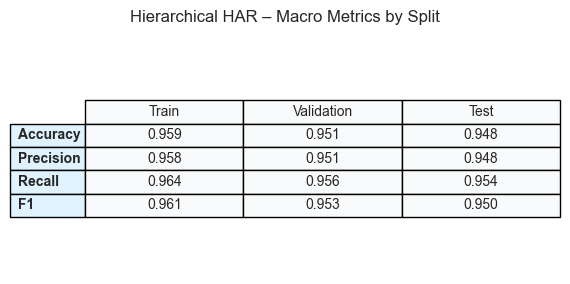


[SUMMARY] Hierarchical HAR – Macro metrics
Train      | Acc=0.959, Prec=0.958, Rec=0.964, F1=0.961
Validation | Acc=0.951, Prec=0.951, Rec=0.956, F1=0.953
Test       | Acc=0.948, Prec=0.948, Rec=0.954, F1=0.950


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

def _basic_metrics_for_split(X, y, average="macro"):
    y = np.asarray(y, dtype=int)
    y_pred = hierarchical_predict_4class(X)

    return {
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, average=average, zero_division=0),
        "recall":    recall_score(y, y_pred, average=average, zero_division=0),
        "f1":        f1_score(y, y_pred, average=average, zero_division=0),
    }

def plot_har_metrics_grid(
    X_tr, y_tr,
    X_val, y_val,
    X_te, y_te,
    average="macro",
    title="Hierarchical HAR – Macro Metrics by Split",
):
    # 1) Compute metrics for each split
    metrics_tr  = _basic_metrics_for_split(X_tr,  y_tr,  average=average)
    metrics_val = _basic_metrics_for_split(X_val, y_val, average=average)
    metrics_te  = _basic_metrics_for_split(X_te,  y_te,  average=average)

    metric_names = ["accuracy", "precision", "recall", "f1"]
    split_names  = ["Train", "Validation", "Test"]
    metrics_all  = [metrics_tr, metrics_val, metrics_te]

    # 2) Build cell text: rows=metrics, cols=splits
    cell_text = []
    for metric in metric_names:
        row = [f"{m[metric]:.3f}" for m in metrics_all]
        cell_text.append(row)

    row_labels = [m.capitalize() for m in metric_names]
    col_labels = split_names

    # 3) Plot as a table (grid with numbers)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)  # a bit more spacing

    # --- Pastel colours ---
    header_bg   = "#fce7f3"  # pastel pink
    rowlabel_bg = "#e0f2fe"  # pastel blue
    body_bg     = "#f9fafb"  # very light grey

    for (row, col), cell in table.get_celld().items():
        # Column headers: row = -1, col >= 0
        if row == -1 and col >= 0:
            cell.set_facecolor(header_bg)
            cell.set_text_props(weight="bold")
        # Row headers: col = -1, row >= 0
        elif col == -1 and row >= 0:
            cell.set_facecolor(rowlabel_bg)
            cell.set_text_props(weight="bold")
        # Corner cell (top-left)
        elif row == -1 and col == -1:
            cell.set_facecolor("#ffffff")
        # Data cells
        else:
            cell.set_facecolor(body_bg)

    fig.suptitle(title, fontsize=12, y=0.94)
    plt.tight_layout()
    plt.show()

    # 4) Text summary in console (optional)
    print("\n[SUMMARY] Hierarchical HAR – Macro metrics")
    for split_name, m in zip(split_names, metrics_all):
        print(
            f"{split_name:10s} | "
            f"Acc={m['accuracy']:.3f}, "
            f"Prec={m['precision']:.3f}, "
            f"Rec={m['recall']:.3f}, "
            f"F1={m['f1']:.3f}"
        )

plot_har_metrics_grid(
    X_tr=Xf_tr, y_tr=yf_tr,
    X_val=Xf_val, y_val=yf_val,
    X_te=Xf_te, y_te=yf_te,
    average="macro",
)



# 6. Export ONXX

In [ ]:
# Build compact feature space for export to ONXX (that c++ can use so we don't overcompute)

# feat_names currently corresponds to *all* columns in Xf_* (full feature space)
feat_names = list(feat_names)

# 1) Union of all features used by any of the three models (by column index)
used_idx = sorted(set(sel_idx) | set(sel_static_idx) | set(sel_dyn_idx))

# 2) Mapping from "old" global index -> "new" compact index
old_to_new = {old: new for new, old in enumerate(used_idx)}

# 3) Compact feature name list: only features we actually use anywhere
feat_names_compact = [feat_names[i] for i in used_idx]

# 4) Remap each model's index list into this compact space *preserving order*
int_sel_idx_compact    = [old_to_new[i] for i in sel_idx]
static_sel_idx_compact = [old_to_new[i] for i in sel_static_idx]
dyn_sel_idx_compact    = [old_to_new[i] for i in sel_dyn_idx]

print("[EXPORT] Full feature dim:", len(feat_names))
print("[EXPORT] Compact feature dim:", len(feat_names_compact))
print("[EXPORT] Intensity uses:", len(int_sel_idx_compact), "features")
print("[EXPORT] Static uses   :", len(static_sel_idx_compact), "features")
print("[EXPORT] Dynamic uses  :", len(dyn_sel_idx_compact), "features")



[EXPORT] Full feature dim: 42
[EXPORT] Compact feature dim: 23
[EXPORT] Intensity uses: 4 features
[EXPORT] Static uses   : 14 features
[EXPORT] Dynamic uses  : 11 features


In [ ]:
import importlib
import ExportONXX
importlib.reload(ExportONXX)
from ExportONXX import export_har_hierarchy
import onnxruntime as ort

export_paths = export_har_hierarchy(
    intensity_model=intensity_clf,
    static_model=static_svm,
    dynamic_model=dyn_svm,
    feat_names=feat_names_compact,
    int_sel_idx=int_sel_idx_compact,
    static_sel_idx=static_sel_idx_compact,
    dyn_sel_idx=dyn_sel_idx_compact,
    label_name_to_id=LABEL_NAME_TO_ID,
    mode="per_person",    # or "general"
    person="veron",
)

print(export_paths)


[EXPORT] Saving ONNX models to: models\veron
[ONNX] Saved → models\veron\har_intensity.onnx
[ONNX] Saved → models\veron\har_static.onnx
[ONNX] Saved → models\veron\har_dynamic.onnx
[META] Saved models\veron\har_hierarchy_meta.json
{'onnx_intensity': 'models\\veron\\har_intensity.onnx', 'onnx_static': 'models\\veron\\har_static.onnx', 'onnx_dynamic': 'models\\veron\\har_dynamic.onnx', 'meta': 'models\\veron\\har_hierarchy_meta.json'}


### UNIT-TEST: Verify ONXX is functional in Python before trying in C++:

For each of the three SVMs (intensity / static / dynamic), as well as the full pipeline, check:

(A) If fed the same TRAINING examples to:
1. The original sklearn model (using original feature spac + sel_* indices), and
2. The exported ONNX model (using compact feature-space + sel_idx_compact)
Are the same predicted labels achieved at all levels?

(B) If fed the same REAL-TIME FEATURE VECTORS to 1 and 2, are the same predicted labels achieved at all levels?

In [ ]:
# (1) TEST TRAINING EXAMPLES ON INDIVIDUAL SVMS 

# Make compact features
Xf_tr_compact = Xf_tr[:, used_idx].astype(np.float32)

# Take 32 random rows from Xf_tr for testing
rng = np.random.default_rng(0)
idx = rng.choice(Xf_tr.shape[0], size=32, replace=False)

X_batch_full   = Xf_tr[idx]               # full features
X_batch_comp   = Xf_tr_compact[idx]       # compact features
y_batch_true   = yf_tr[idx]

# Load ONNX models using onnx runtime (as we would in c++)
sess_int = ort.InferenceSession("models/veron/har_intensity.onnx", providers=["CPUExecutionProvider"])
sess_sta = ort.InferenceSession("models/veron/har_static.onnx",    providers=["CPUExecutionProvider"])
sess_dyn = ort.InferenceSession("models/veron/har_dynamic.onnx",   providers=["CPUExecutionProvider"])
# Each ONNX graph can have its own input name; fetch them explicitly
input_name_int = sess_int.get_inputs()[0].name
input_name_sta = sess_sta.get_inputs()[0].name
input_name_dyn = sess_dyn.get_inputs()[0].name

# ---------- INTENSITY BRANCH ----------
# Sklearn was trained on *full* space with sel_idx
X_int_skl_in   = X_batch_full[:, sel_idx]
y_int_skl      = intensity_clf.predict(X_int_skl_in) # intensity_clf is pure sklearn model 

# ONNX uses compact indices from metadata
X_int_onnx_in  = X_batch_comp[:, int_sel_idx_compact]
y_int_onnx     = sess_int.run(None, {input_name_int: X_int_onnx_in})[0].ravel()

print("Sklearn intensity preds:", y_int_skl[:10])
print("ONNX    intensity preds:", y_int_onnx[:10])
print("Match? ", np.allclose(y_int_skl, y_int_onnx))

# ---------- STATIC BRANCH ----------
mask_static = np.isin(y_batch_true, [LABEL_NAME_TO_ID["stand"], LABEL_NAME_TO_ID["sit"]])

X_static_full = X_batch_full[mask_static]
X_static_comp = X_batch_comp[mask_static]

X_sta_skl_in  = X_static_full[:, sel_static_idx]
X_sta_onnx_in = X_static_comp[:, static_sel_idx_compact]

y_sta_skl     = static_svm.predict(X_sta_skl_in)
y_sta_onnx    = sess_sta.run(None, {input_name_sta: X_sta_onnx_in})[0].ravel()

print("Static Sklearn preds:", y_sta_skl[:10])
print("Static ONNX    preds:", y_sta_onnx[:10])
print("Static match? ", np.allclose(y_sta_skl, y_sta_onnx))

# ---------- DYNAMIC BRANCH ----------
mask_dyn = np.isin(y_batch_true, [LABEL_NAME_TO_ID["walk"], LABEL_NAME_TO_ID["turn"]])

X_dyn_full = X_batch_full[mask_dyn]
X_dyn_comp = X_batch_comp[mask_dyn]

X_dyn_skl_in  = X_dyn_full[:, sel_dyn_idx]
X_dyn_onnx_in = X_dyn_comp[:, dyn_sel_idx_compact]

y_dyn_skl     = dyn_svm.predict(X_dyn_skl_in)
y_dyn_onnx    = sess_dyn.run(None, {input_name_dyn: X_dyn_onnx_in})[0].ravel()

print("Dynamic Sklearn preds:", y_dyn_skl[:10])
print("Dynamic ONNX    preds:", y_dyn_onnx[:10])
print("Dynamic match? ", np.allclose(y_dyn_skl, y_dyn_onnx))

print("intensity classes_", intensity_clf.classes_)
print("static classes_   ", static_svm.classes_)
print("dynamic classes_  ", dyn_svm.classes_)





Sklearn intensity preds: [1 1 1 0 1 0 1 1 1 1]
ONNX    intensity preds: [1 1 1 0 1 0 1 1 1 1]
Match?  True
Static Sklearn preds: [0 0 0 1 0 0 0 0 0 0]
Static ONNX    preds: [0 0 0 1 0 0 0 0 0 0]
Static match?  True
Dynamic Sklearn preds: [1 0 1 0 1 1 0 0 0 1]
Dynamic ONNX    preds: [1 0 1 0 1 1 0 0 0 1]
Dynamic match?  True
intensity classes_ [0 1]
static classes_    [0 1]
dynamic classes_   [0 1]


In [ ]:
# (2) ENTIRE PIPELINE TEST ON TRAINING EXAMPLES

INT_STATIC_ID  = 0 
INT_DYNAMIC_ID = 1 

def predict_hier_onnx(X_all_compact: np.ndarray) -> np.ndarray:
    """
    Hierarchical prediction using the ONNX models.

    X_all_compact: (N, n_features_compact) in the SAME order as meta["feat_names"]
                   i.e. Xf_tr[:, used_idx].
    Returns: (N,) int labels in the SAME encoding as yf_tr (0..3),
             via LABEL_NAME_TO_ID.
    """
    X_all_compact = np.asarray(X_all_compact, dtype=np.float32)
    N = X_all_compact.shape[0]

    # ---------- 1) INTENSITY: static vs dynamic ----------
    # Use the compact indices we exported with (int_sel_idx_compact)
    X_int = X_all_compact[:, int_sel_idx_compact]
    y_int = sess_int.run(
        None,
        {input_name_int: X_int}
    )[0].ravel().astype(int)   # 0=static, 1=dynamic

    y_pred = np.empty(N, dtype=int)

    # ---------- 2) STATIC BRANCH: stand vs sit ----------
    mask_static = (y_int == INT_STATIC_ID)
    if np.any(mask_static):
        X_sta = X_all_compact[mask_static][:, static_sel_idx_compact]
        y_sta = sess_sta.run(
            None,
            {input_name_sta: X_sta}
        )[0].ravel().astype(int)   # assume 0=stand, 1=sit

        y_pred[mask_static] = np.where(
            y_sta == 0,
            LABEL_NAME_TO_ID["stand"],
            LABEL_NAME_TO_ID["sit"],
        )

    # ---------- 3) DYNAMIC BRANCH: walk vs turn ----------
    mask_dyn = (y_int == INT_DYNAMIC_ID)
    if np.any(mask_dyn):
        X_dyn = X_all_compact[mask_dyn][:, dyn_sel_idx_compact]
        y_dyn = sess_dyn.run(
            None,
            {input_name_dyn: X_dyn}
        )[0].ravel().astype(int)   # assume 0=walk, 1=turn

        y_pred[mask_dyn] = np.where(
            y_dyn == 0,
            LABEL_NAME_TO_ID["walk"],
            LABEL_NAME_TO_ID["turn"],
        )

    return y_pred


def predict_hier_sklearn(X_all_full: np.ndarray) -> np.ndarray:
    """
    Hierarchical prediction using ONLY sklearn models.

    X_all_full: (N, n_features_full) in the SAME order as the original Xf_tr
                (the space where sel_idx / sel_static_idx / sel_dyn_idx live).

    Returns: (N,) int labels in SAME encoding as yf_tr (0..3).
    """
    X_all_full = np.asarray(X_all_full, dtype=np.float32)
    N = X_all_full.shape[0]

    # ---------- 1) INTENSITY: static vs dynamic ----------
    X_int = X_all_full[:, sel_idx]               # full-space indices
    y_int = intensity_clf.predict(X_int).astype(int)  # 0=static, 1=dynamic

    y_pred = np.empty(N, dtype=int)

    # ---------- 2) STATIC BRANCH: stand vs sit ----------
    mask_static = (y_int == INT_STATIC_ID)
    if np.any(mask_static):
        X_sta = X_all_full[mask_static][:, sel_static_idx]
        y_sta = static_svm.predict(X_sta).astype(int)  # 0/1 as per training

        y_pred[mask_static] = np.where(
            y_sta == 0,
            LABEL_NAME_TO_ID["stand"],
            LABEL_NAME_TO_ID["sit"],
        )

    # ---------- 3) DYNAMIC BRANCH: walk vs turn ----------
    mask_dyn = (y_int == INT_DYNAMIC_ID)
    if np.any(mask_dyn):
        X_dyn = X_all_full[mask_dyn][:, sel_dyn_idx]
        y_dyn = dyn_svm.predict(X_dyn).astype(int)     # 0/1 as per training

        y_pred[mask_dyn] = np.where(
            y_dyn == 0,
            LABEL_NAME_TO_ID["walk"],
            LABEL_NAME_TO_ID["turn"],
        )

    return y_pred


def predict_hier_sklearn_compact(X_all_compact: np.ndarray) -> np.ndarray:
    """
    Hierarchical prediction using ONLY sklearn models but in the
    **compact feature space** (same as meta["feat_names"]).

    X_all_compact: (N, n_features_compact) in the SAME order as meta["feat_names"].
    Returns: (N,) int labels in SAME encoding as yf_tr (0..3).
    """
    X_all_compact = np.asarray(X_all_compact, dtype=np.float32)
    N = X_all_compact.shape[0]

    # 1) Intensity: static vs dynamic
    X_int = X_all_compact[:, int_sel_idx_compact]
    y_int = intensity_clf.predict(X_int).astype(int)  # 0=static, 1=dynamic

    y_pred = np.empty(N, dtype=int)

    # 2) Static branch: stand vs sit
    mask_static = (y_int == INT_STATIC_ID)
    if np.any(mask_static):
        X_sta = X_all_compact[mask_static][:, static_sel_idx_compact]
        y_sta = static_svm.predict(X_sta).astype(int)  # 0/1 as per training

        y_pred[mask_static] = np.where(
            y_sta == 0,
            LABEL_NAME_TO_ID["stand"],
            LABEL_NAME_TO_ID["sit"],
        )

    # 3) Dynamic branch: walk vs turn
    mask_dyn = (y_int == INT_DYNAMIC_ID)
    if np.any(mask_dyn):
        X_dyn = X_all_compact[mask_dyn][:, dyn_sel_idx_compact]
        y_dyn = dyn_svm.predict(X_dyn).astype(int)     # 0/1 as per training

        y_pred[mask_dyn] = np.where(
            y_dyn == 0,
            LABEL_NAME_TO_ID["walk"],
            LABEL_NAME_TO_ID["turn"],
        )

    return y_pred


# Full features (for sklearn)
X_tr_full    = Xf_tr.astype(np.float32)

y_hier_skl  = predict_hier_sklearn(X_tr_full)
y_hier_onnx = predict_hier_onnx(Xf_tr_compact)

print("Same shape? ", y_hier_skl.shape == y_hier_onnx.shape)
print("All equal?  ", np.array_equal(y_hier_skl, y_hier_onnx))

LABEL_ID_TO_NAME = {v: k for k, v in LABEL_NAME_TO_ID.items()}
for i in range(20):
    s = int(y_hier_skl[i])
    o = int(y_hier_onnx[i])
    print(
        f"i={i:3d}  skl={s} ({LABEL_ID_TO_NAME[s]})  "
        f"onnx={o} ({LABEL_ID_TO_NAME[o]})"
    )

Same shape?  True
All equal?   True
i=  0  skl=3 (turn)  onnx=3 (turn)
i=  1  skl=3 (turn)  onnx=3 (turn)
i=  2  skl=2 (stand)  onnx=2 (stand)
i=  3  skl=2 (stand)  onnx=2 (stand)
i=  4  skl=2 (stand)  onnx=2 (stand)
i=  5  skl=1 (sit)  onnx=1 (sit)
i=  6  skl=2 (stand)  onnx=2 (stand)
i=  7  skl=2 (stand)  onnx=2 (stand)
i=  8  skl=2 (stand)  onnx=2 (stand)
i=  9  skl=1 (sit)  onnx=1 (sit)
i= 10  skl=0 (walk)  onnx=0 (walk)
i= 11  skl=2 (stand)  onnx=2 (stand)
i= 12  skl=1 (sit)  onnx=1 (sit)
i= 13  skl=0 (walk)  onnx=0 (walk)
i= 14  skl=0 (walk)  onnx=0 (walk)
i= 15  skl=3 (turn)  onnx=3 (turn)
i= 16  skl=2 (stand)  onnx=2 (stand)
i= 17  skl=0 (walk)  onnx=0 (walk)
i= 18  skl=3 (turn)  onnx=3 (turn)
i= 19  skl=3 (turn)  onnx=3 (turn)


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# (3) TEST INDIVIDUAL SVMS ON REAL ACQUIRED FEATURE VECS FROM RUN MODE

def debug_one_vector(ftr_vec):
    """
    Debug a single *compact* feature vector through all three models.

    ftr_vec: 1D array-like of length == len(feat_names_compact)
             (same compact feature order as feat_names_compact /
              meta["feat_names"], e.g. a row from rt_X).
    """
    ftr_vec = np.asarray(ftr_vec, dtype=np.float32).reshape(1, -1)

    # ---------- 1) INTENSITY BRANCH ----------
    X_int = ftr_vec[:, int_sel_idx_compact]

    y_int_skl  = intensity_clf.predict(X_int)
    y_int_onnx = sess_int.run(
        None,
        {input_name_int: X_int.astype(np.float32)}
    )[0].ravel()

    print("== INTENSITY (static vs dynamic) ==")
    print("Sklearn:", y_int_skl)
    print("ONNX   :", y_int_onnx)
    print("Match? ", np.allclose(y_int_skl, y_int_onnx))

    # ---------- 2) STATIC BRANCH (stand vs sit) ----------
    X_sta = ftr_vec[:, static_sel_idx_compact]

    y_sta_skl  = static_svm.predict(X_sta)
    y_sta_onnx = sess_sta.run(
        None,
        {input_name_sta: X_sta.astype(np.float32)}
    )[0].ravel()

    print("\n== STATIC (stand vs sit) ==")
    print("Sklearn:", y_sta_skl)
    print("ONNX   :", y_sta_onnx)
    print("Match? ", np.allclose(y_sta_skl, y_sta_onnx))

    # ---------- 3) DYNAMIC BRANCH (walk vs turn) ----------
    X_dyn = ftr_vec[:, dyn_sel_idx_compact]

    y_dyn_skl  = dyn_svm.predict(X_dyn)
    y_dyn_onnx = sess_dyn.run(
        None,
        {input_name_dyn: X_dyn.astype(np.float32)}
    )[0].ravel()

    print("\n== DYNAMIC (walk vs turn) ==")
    print("Sklearn:", y_dyn_skl)
    print("ONNX   :", y_dyn_onnx)
    print("Match? ", np.allclose(y_dyn_skl, y_dyn_onnx))


rt_csv_path = Path(
    r"C:\Users\fsdma\OneDrive\Documents\Uni Year 4\IBEHS 4QZ3\HARSys\data\ftrs\rt_features_veronica_2.csv"
)

rt_df = pd.read_csv(rt_csv_path)

# ---- 1) allow missing compact feature cols, but warn ----
cols_in_common = [c for c in feat_names_compact if c in rt_df.columns]
missing = [c for c in feat_names_compact if c not in rt_df.columns]

if missing:
    print("[WARN] Missing feature columns in rt_features CSV (will be zero-filled):")
    for m in missing:
        print("   -", m)

# ---- 2) build feature matrix in EXACT compact order, zero-filling missing ----
rt_X = (
    rt_df[cols_in_common]
    .reindex(columns=feat_names_compact, fill_value=0.0)
    .to_numpy(dtype=np.float32)
)
print("rt_X shape:", rt_X.shape)

# (4) End-to-end hierarchical pipeline comparison on REAL RT features
rt_X_compact = rt_X.astype(np.float32)

y_rt_skl  = predict_hier_sklearn_compact(rt_X_compact)
y_rt_onnx = predict_hier_onnx(rt_X_compact)

print("RT: Same shape? ", y_rt_skl.shape == y_rt_onnx.shape)
print("RT: All equal?  ", np.array_equal(y_rt_skl, y_rt_onnx))

LABEL_ID_TO_NAME = {v: k for k, v in LABEL_NAME_TO_ID.items()}

for i in range(min(30, rt_X_compact.shape[0])):
    s = int(y_rt_skl[i])
    o = int(y_rt_onnx[i])
    print(
        f"i={i:3d}  skl={s} ({LABEL_ID_TO_NAME.get(s, '?')})  "
        f"onnx={o} ({LABEL_ID_TO_NAME.get(o, '?')})"
    )


def debug_row(idx: int):
    print(f"\n================= ROW {idx} =================")
    ftr_vec = rt_X[idx]  # 1D compact feature vector
    debug_one_vector(ftr_vec)


# Debugging random rows
N = rt_X.shape[0]
n_to_check = min(20, N)

rng = np.random.default_rng(42)
idxs = rng.choice(N, size=n_to_check, replace=False)

print("Debugging random rows:", idxs)
for i in idxs:
    debug_row(int(i))

# (5) Check diffs in magnitudes between training and real time features (generalizability / consistency)

keys = ['std_y', 'std_mag', 'tilt_variability', 'total_power_mag']

for k in keys:
    if k not in feat_names_compact:
        print(f"\nFeature: {k} (not in feat_names_compact, skipping)")
        continue

    i = feat_names_compact.index(k)

    # If Xf_tr_compact is the matrix that was used to train intensity
    tr_vals = Xf_tr_compact[:, i]

    # rt_X is already in the same compact feature order as feat_names_compact
    rt_vals = rt_X[:, i]

    print(f"\nFeature: {k}")
    print("  Train min/max:", float(tr_vals.min()), float(tr_vals.max()))
    print("  RT    min/max:", float(rt_vals.min()), float(rt_vals.max()))


[WARN] Missing feature columns in rt_features CSV (will be zero-filled):
   - mean_y
   - std_z
   - sma_xyz
   - mean_mag
   - mad_mag
   - spectral_entropy_mag
   - ar4_c1
   - ar4_c2
   - ar4_c4
   - dom_freq_mag
rt_X shape: (361, 23)
RT: Same shape?  True
RT: All equal?   True
i=  0  skl=2 (stand)  onnx=2 (stand)
i=  1  skl=2 (stand)  onnx=2 (stand)
i=  2  skl=2 (stand)  onnx=2 (stand)
i=  3  skl=2 (stand)  onnx=2 (stand)
i=  4  skl=2 (stand)  onnx=2 (stand)
i=  5  skl=2 (stand)  onnx=2 (stand)
i=  6  skl=2 (stand)  onnx=2 (stand)
i=  7  skl=2 (stand)  onnx=2 (stand)
i=  8  skl=2 (stand)  onnx=2 (stand)
i=  9  skl=2 (stand)  onnx=2 (stand)
i= 10  skl=2 (stand)  onnx=2 (stand)
i= 11  skl=2 (stand)  onnx=2 (stand)
i= 12  skl=2 (stand)  onnx=2 (stand)
i= 13  skl=2 (stand)  onnx=2 (stand)
i= 14  skl=2 (stand)  onnx=2 (stand)
i= 15  skl=2 (stand)  onnx=2 (stand)
i= 16  skl=2 (stand)  onnx=2 (stand)
i= 17  skl=2 (stand)  onnx=2 (stand)
i= 18  skl=2 (stand)  onnx=2 (stand)
i= 19  skl=2 (s

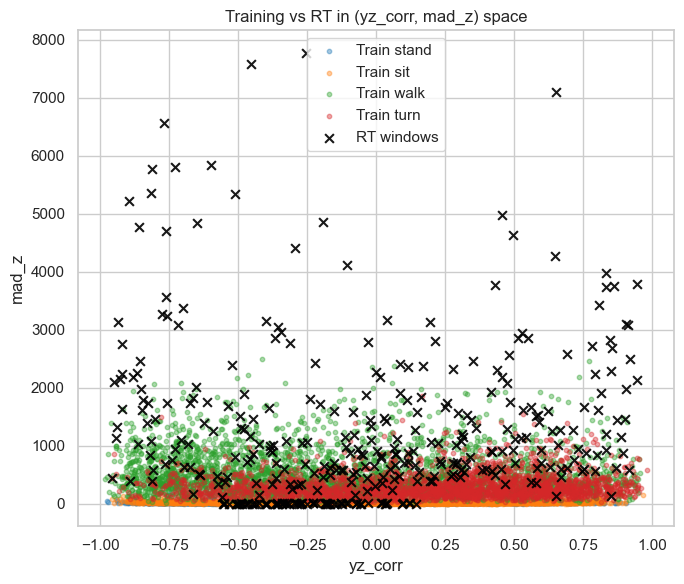

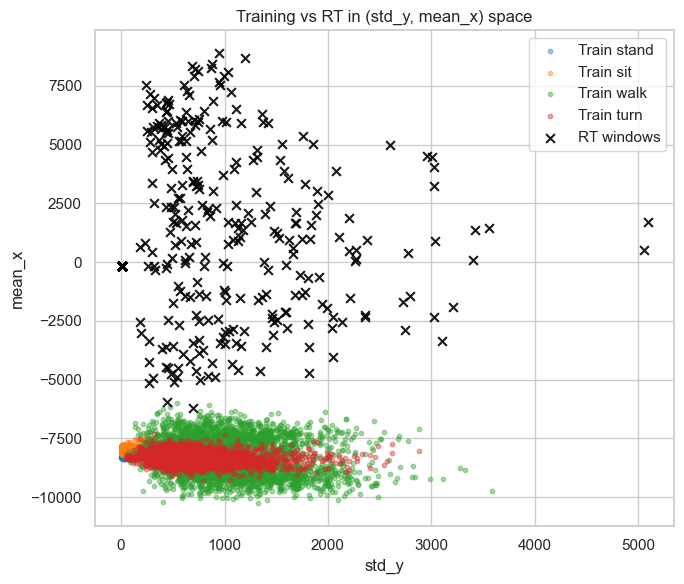

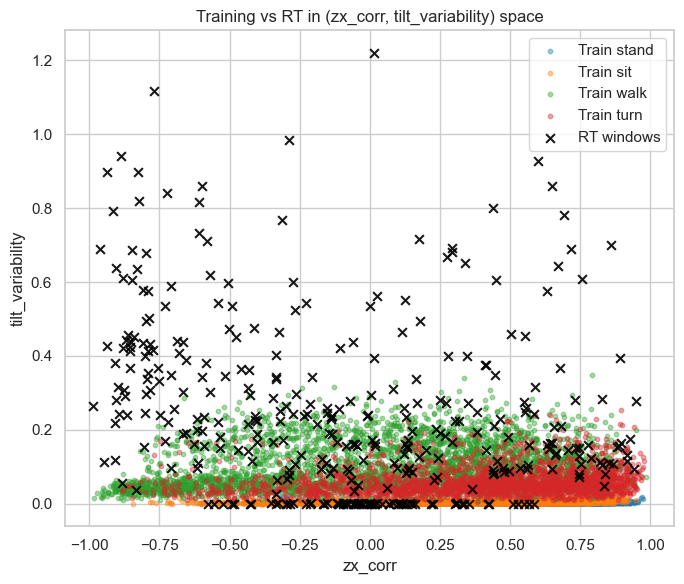

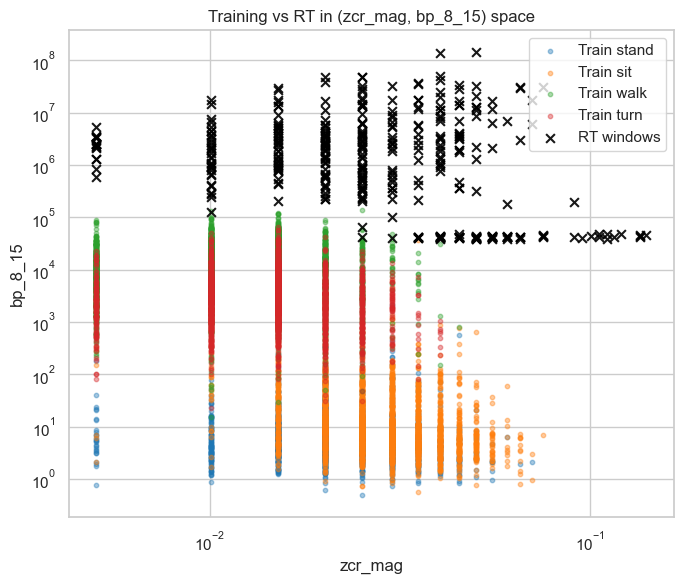

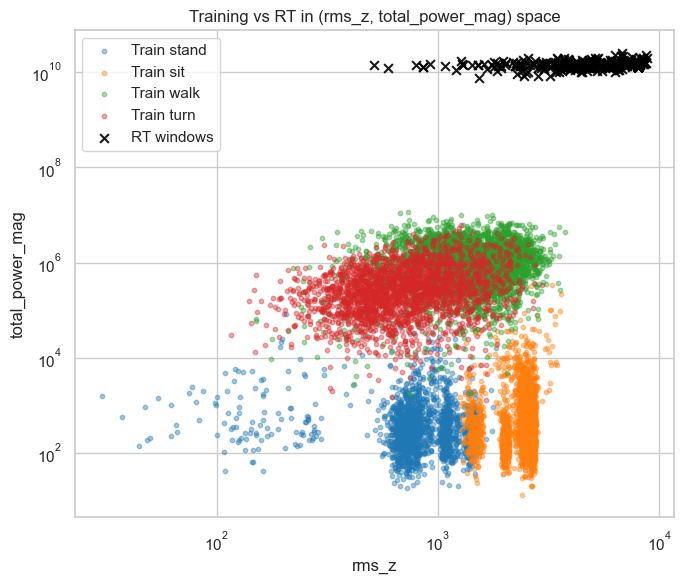

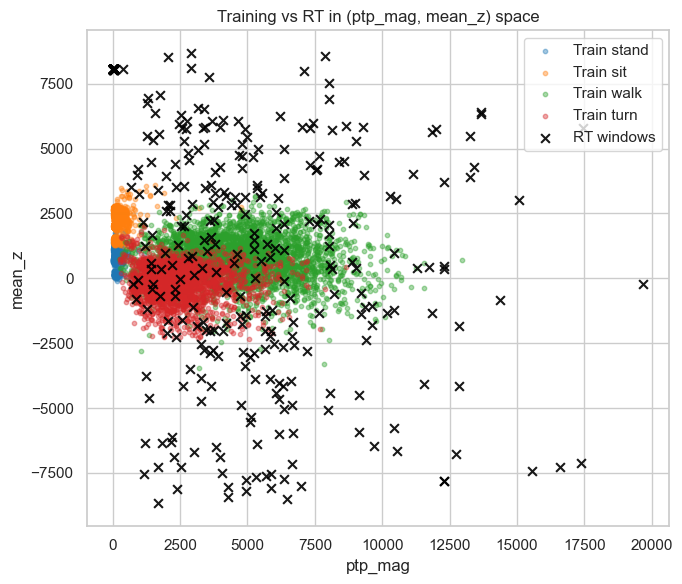

In [ ]:
# 6) VISUALIZE FTR VECS (RT VS TRAIN) IN RANDOM 2D SPACES

# 1) figure out which features are *actually* present in RT CSV
#    (i.e., columns that existed before reindex, not just zero-filled)
available_rt_feats = [c for c in feat_names_compact if c in rt_df.columns]

if len(available_rt_feats) < 2:
    print("[WARN] Fewer than 2 RT features available; skipping 2D visualizations.")
else:
    # how many random 2D plots to make
    n_plots = min(9, len(available_rt_feats) // 2)

    rng = np.random.default_rng(123)
    # pick a small subset of distinct features to pair up
    n_sample_feats = min(2 * n_plots, len(available_rt_feats))
    sampled_feats = list(rng.choice(available_rt_feats, size=n_sample_feats, replace=False))

    # make pairs: (0,1), (2,3), ...
    pairs = [(sampled_feats[2*i], sampled_feats[2*i + 1]) for i in range(n_plots)]

    X_tr_c = Xf_tr_compact  # compact training features
    X_rt_c = rt_X           # compact RT features (already in compact order)

    # Training labels (0..3)
    y_tr = yf_tr

    # Colour map for 4 classes
    colmap = {
        LABEL_NAME_TO_ID["stand"]: "tab:blue",
        LABEL_NAME_TO_ID["sit"]:   "tab:orange",
        LABEL_NAME_TO_ID["walk"]:  "tab:green",
        LABEL_NAME_TO_ID["turn"]:  "tab:red",
    }

    for f1, f2 in pairs:
        i1 = feat_names_compact.index(f1)
        i2 = feat_names_compact.index(f2)

        tr_f1 = X_tr_c[:, i1]
        tr_f2 = X_tr_c[:, i2]
        rt_f1 = X_rt_c[:, i1]
        rt_f2 = X_rt_c[:, i2]

        plt.figure(figsize=(7, 6))

        for cls_id, color in colmap.items():
            mask = (y_tr == cls_id)
            if not np.any(mask):
                continue
            # recover label name string (e.g., "stand") for legend
            cls_name = [k for k, v in LABEL_NAME_TO_ID.items() if v == cls_id][0]
            plt.scatter(
                tr_f1[mask],
                tr_f2[mask],
                s=10,
                alpha=0.4,
                label=f"Train {cls_name}",
                c=color,
            )

        # Overlay RT points
        plt.scatter(
            rt_f1,
            rt_f2,
            s=40,
            marker="x",
            linewidths=1.5,
            alpha=0.9,
            c="black",
            label="RT windows",
        )

        plt.xlabel(f1)
        plt.ylabel(f2)

        # optional: if both are strictly positive, log scale can be nice
        if np.all(tr_f1 > 0) and np.all(tr_f2 > 0) and np.all(rt_f1 > 0) and np.all(rt_f2 > 0):
            plt.xscale("log")
            plt.yscale("log")

        plt.legend()
        plt.title(f"Training vs RT in ({f1}, {f2}) space")
        plt.tight_layout()
        plt.show()



### Feature Extractor Consistency Test
This is to check whether the feature extraction in C++ matches that in Python, i.e. for a given window, both platforms compute the same feature values. If there were inconsistencies, this would bias real-time operation.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# New C++ feature+raw CSV (features + x0,y0,z0,...)
RT_FTR_RAW_CSV = Path(
    r"C:\Users\fsdma\OneDrive\Documents\Uni Year 4\IBEHS 4QZ3\HARSys\data\ftrs\rt_features_with_raw_veronica_3.csv"
)

CPP_FS = 119.0      # must match C++ sampling rate
CPP_AR_ORDER = 4    # must match AR order used in C++


def compare_cpp_python_features(
    csv_path: Path,
    compact_feature_names: list[str],   # e.g. feat_names_compact (expanded)
    base_feature_names: list[str],      # e.g. selected_features (templates)
    fs: float = CPP_FS,
    ar_order: int = CPP_AR_ORDER,
    num_windows_to_check: int = 20,
    atol: float = 1e-5,
    rtol: float = 1e-3,
    rng_seed: int = SEED,
):
    """
    Load rt_features_veronica_2.csv and verify that the feature columns
    computed in C++ match Python's compute_features() for a random subset
    of windows.

    - compact_feature_names: full expanded list, e.g. feat_names_compact
    - base_feature_names: the base template list used when training / in C++,
      e.g. selected_features:
          ["mean_axis", "std_axis", ..., "bandpowers_mag", "ar_mag_coeffs", ...]
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    # 1) Which features can we actually compare? (intersection)
    common_feats = [name for name in compact_feature_names if name in df.columns]
    missing_feats = [name for name in compact_feature_names if name not in df.columns]

    if not common_feats:
        raise ValueError(
            f"{csv_path} has none of the requested compact features. "
            f"Requested={len(compact_feature_names)}, available={len(df.columns)}"
        )

    if missing_feats:
        print(f"[WARN] {csv_path} is missing {len(missing_feats)} compact features; "
              f"only comparing {len(common_feats)} that exist in the CSV.")

    feat_cols = list(common_feats)  # compact features to compare, in canonical order

    # 2) Identify raw window columns: x0,y0,z0,...,xL-1,yL-1,zL-1
    #    (strictly xN/yN/zN, not things like yz_corr)
    raw_cols = [
        c for c in df.columns
        if len(c) >= 2 and (c[0] in "xyz") and c[1:].isdigit()
    ]
    if not raw_cols:
        raise ValueError(f"{csv_path} has no raw xN/yN/zN columns")

    if len(raw_cols) % 3 != 0:
        raise ValueError(
            f"{csv_path}: number of raw cols ({len(raw_cols)}) not divisible by 3 "
            f"(are all xN/yN/zN columns present and named correctly?)"
        )

    win_len_samples = len(raw_cols) // 3
    print(f"[CHECK] Found {len(df)} windows, win_len={win_len_samples} samples")
    print(f"[CHECK] Comparing {len(feat_cols)} compact features against Python recomputation.")

    # 3) Choose random subset of windows
    n = len(df)
    k = min(num_windows_to_check, n)
    rng = np.random.default_rng(rng_seed)
    idxs = rng.choice(n, size=k, replace=False)

    max_abs_diff_global = 0.0
    per_feature_max_diff: dict[str, float] = {name: 0.0 for name in feat_cols}
    num_fail = 0

    for idx in idxs:
        row = df.iloc[idx]

        # a) C++ feature vector (only for the common compact features)
        cpp_fv = row[feat_cols].to_numpy(dtype=float)

        # b) Raw window -> Python FULL feature vector using base specs
        raw_flat = row[raw_cols].to_numpy(dtype=float)
        xw, yw, zw = split_xyz_from_flat(raw_flat)

        py_fv_full, py_dict_full = compute_features(
            xw, yw, zw,
            fs=fs,
            feature_names=base_feature_names,  # templates (mean_axis, bandpowers_mag, ar_mag_coeffs, ...)
            ar_order=ar_order,
        )

        # c) Build compact Python vector in the *same order* as feat_cols
        try:
            py_fv = np.array([py_dict_full[name] for name in feat_cols], dtype=float)
        except KeyError as e:
            missing_key = str(e)
            raise KeyError(
                f"Python compute_features() did not produce key {missing_key}. "
                f"Make sure base_feature_names includes the right templates "
                f"(e.g. 'ar_mag_coeffs', 'bandpowers_mag', 'mean_axis', etc.)."
            )

        if cpp_fv.shape != py_fv.shape:
            raise ValueError(
                f"Shape mismatch at row {idx}: C++ {cpp_fv.shape} vs Python {py_fv.shape}"
            )

        # d) Compare element-wise
        diffs = np.abs(cpp_fv - py_fv)
        max_abs_diff = float(diffs.max())
        max_abs_diff_global = max(max_abs_diff_global, max_abs_diff)

        # track per-feature maxima
        for j, name in enumerate(feat_cols):
            per_feature_max_diff[name] = max(per_feature_max_diff[name], float(diffs[j]))

        # e) allclose check
        if not np.allclose(cpp_fv, py_fv, atol=atol, rtol=rtol):
            num_fail += 1
            print(f"[MISMATCH] row {idx}: max_abs_diff={max_abs_diff:.3e}")

    print("===============================================")
    print(f"Checked {k} random windows from {n} total")
    print(f"Global max |C++ - Py| = {max_abs_diff_global:.3e}")
    print(f"Windows failing np.allclose (rtol={rtol}, atol={atol}): {num_fail}")
    if num_fail == 0:
        print("[OK] All sampled windows matched within tolerance.")
    else:
        print("[WARN] Some windows exceeded tolerance; inspect per-feature diffs.")

    # Optional: print top few worst features
    sorted_feats = sorted(
        per_feature_max_diff.items(),
        key=lambda kv: kv[1],
        reverse=True,
    )
    print("Top 10 worst per-feature absolute differences:")
    for name, d in sorted_feats[:10]:
        print(f"  {name:25s}: {d:.3e}")

    return per_feature_max_diff


# === Example usage ===
per_feat_diff = compare_cpp_python_features(
    csv_path=RT_FTR_RAW_CSV,
    compact_feature_names=feat_names_compact,  # expanded list used in training/selection
    base_feature_names=selected_features,      # your earlier list with 'ar_mag_coeffs', 'bandpowers_mag', etc.
    fs=FS,
    ar_order=AR_ORDER,
    num_windows_to_check=30,
)


[WARN] C:\Users\fsdma\OneDrive\Documents\Uni Year 4\IBEHS 4QZ3\HARSys\data\ftrs\rt_features_with_raw_veronica_3.csv is missing 6 compact features; only comparing 17 that exist in the CSV.
[CHECK] Found 5844 windows, win_len=200 samples
[CHECK] Comparing 17 compact features against Python recomputation.
[MISMATCH] row 5029: max_abs_diff=2.341e+00
[MISMATCH] row 3518: max_abs_diff=2.836e+00
[MISMATCH] row 449: max_abs_diff=1.884e+00
[MISMATCH] row 4750: max_abs_diff=2.095e+00
[MISMATCH] row 2560: max_abs_diff=2.100e+00
[MISMATCH] row 1522: max_abs_diff=2.835e+00
[MISMATCH] row 5209: max_abs_diff=2.006e+00
[MISMATCH] row 4877: max_abs_diff=1.953e+00
[MISMATCH] row 4778: max_abs_diff=2.037e+00
[MISMATCH] row 4976: max_abs_diff=1.508e+00
[MISMATCH] row 987: max_abs_diff=1.604e+00
[MISMATCH] row 481: max_abs_diff=7.000e+00
[MISMATCH] row 15: max_abs_diff=3.815e+00
[MISMATCH] row 5309: max_abs_diff=1.519e+00
[MISMATCH] row 4597: max_abs_diff=1.952e+00
[MISMATCH] row 5745: max_abs_diff=2.210e+

C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\1416324868.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P, f))
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\1416324868.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P[m], f[m]))
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\1416324868.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P, f))
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\1416324868.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P[m], f[m]))
C:\Users\fsdma\AppData\Local\Temp\ipykernel_1676\1